-----

In [1]:
# def min_max_normalization(x):
#     return (x - x.min()) / (x.max() - x.min())

# def denormalize(df_norm, orig_min, orig_max):
#     return df_norm * (orig_max - orig_min) + orig_min

# numeric_cols = sampled_data.select_dtypes(include=[np.number])

# orig_min = numeric_cols.min()
# orig_max = numeric_cols.max()

# min_max_data = numeric_cols.apply(min_max_normalization)

# min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

# categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
# full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

# min_max_data.head()

In [2]:
# debt_data = full_min_max_data[full_min_max_data['purpose'] == 'debt_consolidation']
# credit_data = full_min_max_data[full_min_max_data['purpose'] == 'credit_card']

In [3]:
# X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.iloc[:, :-3], debt_data['credit.policy'], test_size=0.2, random_state=123)

# X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.iloc[:, :-3], credit_data['credit.policy'], test_size=0.2, random_state=123)

In [4]:
# X_debt, y_debt = debt_data.iloc[:, :-3], debt_data['credit.policy']

# X_credit, y_credit = credit_data.iloc[:, :-3], credit_data['credit.policy']

-----

# Bibliotekos

In [5]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier as AdaBoost
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import SGDClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.manifold import TSNE
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import validation_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, fbeta_score, RocCurveDisplay, roc_auc_score, ConfusionMatrixDisplay

from matplotlib.colors import ListedColormap
from scipy.interpolate import griddata
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.ticker as mtick

# Duomenys

In [6]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [7]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.6, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 5746


In [8]:
print(sampled_data.dtypes)

credit.policy        category
purpose              category
int.rate              float64
installment           float64
log.annual.inc        float64
dti                   float64
fico                    int64
days.with.cr.line     float64
revol.bal               int64
revol.util            float64
inq.last.6mths          int64
delinq.2yrs             int64
pub.rec                 int64
not.fully.paid       category
annual.inc            float64
dtype: object


In [9]:
stats = sampled_data.groupby('credit.policy').agg({
    col: ['min', 'max', 'mean', 'std', lambda x: x.quantile(0.25), 'median', lambda x: x.quantile(0.75)]
    for col in sampled_data.select_dtypes(include=[np.number]).columns 
    if col != 'credit.policy'
})
print(stats.T.to_string())

credit.policy                            0             1
int.rate          min         7.120000e-02  6.000000e-02
                  max         2.121000e-01  2.121000e-01
                  mean        1.390378e-01  1.191069e-01
                  std         2.574585e-02  2.548484e-02
                  <lambda_0>  1.229000e-01  9.760000e-02
                  median      1.392000e-01  1.189000e-01
                  <lambda_1>  1.545000e-01  1.357000e-01
installment       min         1.567000e+01  1.569000e+01
                  max         9.268300e+02  9.144200e+02
                  mean        2.914529e+02  3.255895e+02
                  std         2.092769e+02  2.057023e+02
                  <lambda_0>  1.388675e+02  1.665800e+02
                  median      2.327550e+02  2.771600e+02
                  <lambda_1>  3.851525e+02  4.526000e+02
log.annual.inc    min         7.547502e+00  8.294050e+00
                  max         1.333100e+01  1.452835e+01
                  mean        1

C:\Users\crist\AppData\Local\Temp\ipykernel_35204\2824401904.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = sampled_data.groupby('credit.policy').agg({


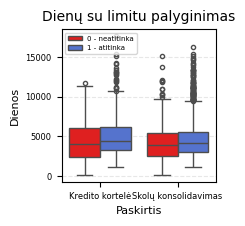

In [10]:
filtered_data = sampled_data[sampled_data['purpose'].isin(['credit_card', 'debt_consolidation'])].copy()

translation_dict = {
    'credit_card': 'Kredito kortelė',
    'debt_consolidation': 'Skolų konsolidavimas'
}
filtered_data['purpose'] = filtered_data['purpose'].map(translation_dict)

if filtered_data['purpose'].dtype.name == 'category' or hasattr(filtered_data['purpose'], 'cat'):
    filtered_data['purpose'] = filtered_data['purpose'].astype('category').cat.remove_unused_categories()

my_palette = {0: "red", 1: "royalblue"}

width_inch = 6 / 2.54
height_inch = 6 / 2.54
plt.figure(figsize=(width_inch, height_inch))

ax = sns.boxplot(
    x='purpose', 
    y='days.with.cr.line', 
    hue='credit.policy', 
    data=filtered_data, 
    palette=my_palette,
    fliersize=3
)

plt.title('Dienų su limitu palyginimas', fontsize=10)
plt.xlabel('Paskirtis', fontsize=8)
plt.ylabel('Dienos', fontsize=8)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    ['0 - neatitinka', '1 - atitinka'], 
    fontsize=5,
    loc='upper left',
    markerscale=0.3
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("dienos_groups.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
debt_data = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data = debt_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
debt_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,0,26.40,697,3840.000000,5132,41.4,2,0,0,0,45000.000056
2157,0,13.02,687,2130.000000,9451,33.3,4,0,0,1,37499.999927
2158,0,19.52,672,4529.958333,8443,33.2,4,1,0,0,38000.000049
2159,0,16.19,672,6360.000000,5494,83.2,4,0,0,0,60999.999808
2160,0,26.52,667,2672.958333,21300,65.5,4,0,0,0,55199.999875


In [12]:
print(debt_data['credit.policy'].value_counts())
print(debt_data['credit.policy'].value_counts(normalize=True))

credit.policy
1    1934
0     440
Name: count, dtype: int64
credit.policy
1    0.814659
0    0.185341
Name: proportion, dtype: float64


In [9]:
credit_data = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data = credit_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
credit_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,0,16.87,677,3779.958333,2488,62.2,5,0,0,0,34999.999983
1400,0,15.14,647,3299.000000,36662,82.9,0,0,0,0,49999.999779
1401,0,4.51,727,600.000000,669,7.0,0,0,0,0,49999.999779
1402,0,6.24,657,2490.000000,8558,80.7,3,0,0,0,71000.000282
1403,0,12.26,702,6960.000000,56200,57.4,4,0,0,0,159999.999325


In [14]:
print(credit_data['credit.policy'].value_counts())
print(credit_data['credit.policy'].value_counts(normalize=True))

credit.policy
1    612
0    145
Name: count, dtype: int64
credit.policy
1    0.808454
0    0.191546
Name: proportion, dtype: float64


In [15]:
X_debt = debt_data.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_debt = debt_data['credit.policy']

X_credit = credit_data.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_credit = credit_data['credit.policy']

In [16]:
X_debt.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
2156,26.40,697,3840.000000,5132,41.4,2,0,0,45000.000056
2157,13.02,687,2130.000000,9451,33.3,4,0,0,37499.999927
2158,19.52,672,4529.958333,8443,33.2,4,1,0,38000.000049
2159,16.19,672,6360.000000,5494,83.2,4,0,0,60999.999808
2160,26.52,667,2672.958333,21300,65.5,4,0,0,55199.999875


In [17]:
debt_data.corr()['credit.policy']

credit.policy        1.000000
dti                 -0.121231
fico                 0.343442
days.with.cr.line    0.080150
revol.bal           -0.180822
revol.util          -0.113900
inq.last.6mths      -0.577683
delinq.2yrs         -0.075885
pub.rec             -0.060436
not.fully.paid      -0.117295
annual.inc           0.006409
Name: credit.policy, dtype: float64

# Algoritmai su numatytais parametrais

## Kredito politika, visi požymiai, specifiškumas

In [18]:
cv_strategy = StratifiedKFold(n_splits=20, shuffle=True, random_state=123)
specificity_scorer = make_scorer(recall_score, pos_label=0)

### SVC

In [19]:
svc_pipeline = make_pipeline(MinMaxScaler(), svm.SVC())

# scores_svc_debt = cross_val_score(svc_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_svc_debt.mean()}")

# scores_svc_credit = cross_val_score(svc_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_svc_credit.mean()}")


scores_svc_debt = cross_val_score(svc_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_svc_debt.mean():.4f}")

scores_svc_credit = cross_val_score(svc_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_svc_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.6705
Kredito kortelės (Specifiškumas): 0.4482


### AdaBoost

In [20]:
AdaBoost_pipeline = make_pipeline(MinMaxScaler(), AdaBoost())

# scores_AdaBoost_debt = cross_val_score(svc_AdaBoost_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_AdaBoost_debt.mean()}")

# scores_AdaBoost_credit = cross_val_score(svc_AdaBoost_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_AdaBoost_credit.mean()}")

scores_AdaBoost_debt = cross_val_score(AdaBoost_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_AdaBoost_debt.mean():.4f}")

scores_AdaBoost_credit = cross_val_score(AdaBoost_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_AdaBoost_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.8705
Kredito kortelės (Specifiškumas): 0.7366


### Bernoulli naive bayes

In [21]:
BernoulliNB_pipeline = make_pipeline(MinMaxScaler(), BernoulliNB())

# scores_BernoulliNB_debt = cross_val_score(svc_BernoulliNB_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_BernoulliNB_debt.mean()}")

# scores_BernoulliNB_credit = cross_val_score(svc_BernoulliNB_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_BernoulliNB_credit.mean()}")

scores_BernoulliNB_debt = cross_val_score(BernoulliNB_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_BernoulliNB_debt.mean():.4f}")

scores_BernoulliNB_credit = cross_val_score(BernoulliNB_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_BernoulliNB_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.0045
Kredito kortelės (Specifiškumas): 0.0286


### Logistic Regression

In [22]:
lr_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression())

# scores_lr_debt = cross_val_score(svc_lr_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_lr_debt.mean()}")

# scores_lr_credit = cross_val_score(svc_lr_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_lr_credit.mean()}")

scores_lr_debt = cross_val_score(lr_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_lr_debt.mean():.4f}")

scores_lr_credit = cross_val_score(lr_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_lr_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.5386
Kredito kortelės (Specifiškumas): 0.2473


### Gradient Boosting

In [23]:
gb_pipeline = make_pipeline(MinMaxScaler(), GradientBoostingClassifier())

# scores_gb_debt = cross_val_score(gb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_gb_debt.mean()}")

# scores_gb_credit = cross_val_score(gb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_gb_credit.mean()}")

scores_gb_debt = cross_val_score(gb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gb_debt.mean():.4f}")

scores_gb_credit = cross_val_score(gb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gb_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.9682
Kredito kortelės (Specifiškumas): 0.8893


### Gaussian Naive Bayes

In [24]:
gnb_pipeline = make_pipeline(MinMaxScaler(), GaussianNB())

# scores_gnb_debt = cross_val_score(gnb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_gnb_debt.mean()}")

# scores_gnb_credit = cross_val_score(gnb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_gnb_credit.mean()}")

scores_gnb_debt = cross_val_score(gnb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gnb_debt.mean():.4f}")

scores_gnb_credit = cross_val_score(gnb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gnb_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.6455
Kredito kortelės (Specifiškumas): 0.4884


### Random Forest

In [25]:
rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier())

# scores_rf_debt = cross_val_score(rf_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_rf_debt.mean()}")

# scores_rf_credit = cross_val_score(rf_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_rf_credit.mean()}")

scores_rf_debt = cross_val_score(rf_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_rf_debt.mean():.4f}")

scores_rf_credit = cross_val_score(rf_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_rf_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.9591
Kredito kortelės (Specifiškumas): 0.8893


### K-Nearest Neighbors

In [26]:
knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier())

# scores_knn_debt = cross_val_score(knn_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_knn_debt.mean()}")

# scores_knn_credit = cross_val_score(knn_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_knn_credit.mean()}")

scores_knn_debt = cross_val_score(knn_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_knn_debt.mean():.4f}")

scores_knn_credit = cross_val_score(knn_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_knn_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.5364
Kredito kortelės (Specifiškumas): 0.3107


### Passive Aggressive

In [27]:
pa_pipeline = make_pipeline(MinMaxScaler(), PassiveAggressiveClassifier())

# scores_pa_debt = cross_val_score(pa_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_pa_debt.mean()}")

# scores_pa_credit = cross_val_score(pa_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_pa_credit.mean()}")

scores_pa_debt = cross_val_score(pa_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_pa_debt.mean():.4f}")

scores_pa_credit = cross_val_score(pa_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_pa_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.5818


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packag

Kredito kortelės (Specifiškumas): 0.6295


-----

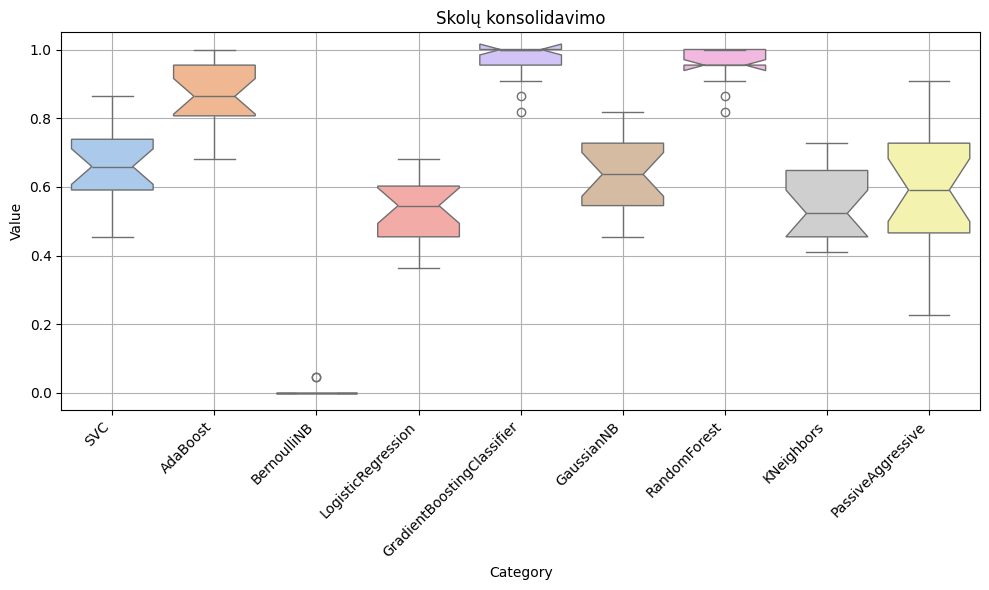

In [28]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_debt, scores_AdaBoost_debt, scores_BernoulliNB_debt, scores_lr_debt, scores_gb_debt, scores_gnb_debt, scores_rf_debt, scores_knn_debt, scores_pa_debt])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

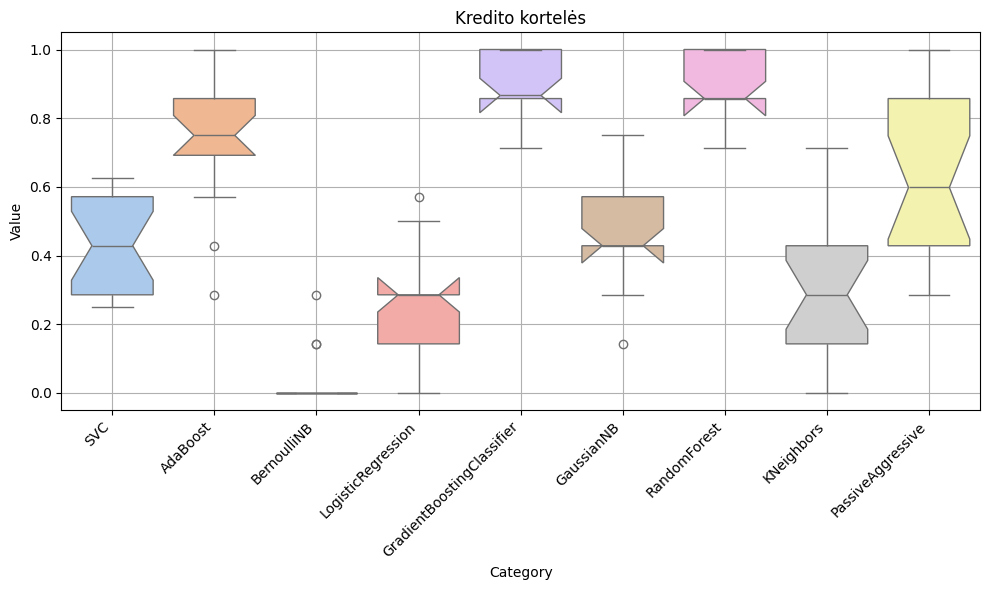

In [29]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_credit, scores_AdaBoost_credit, scores_BernoulliNB_credit, scores_lr_credit, scores_gb_credit, scores_gnb_credit, scores_rf_credit, scores_knn_credit, scores_pa_credit])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

## Kredito politika, atrinkti požymiai, specifiškumas

In [460]:
sampled_data_for_cor = sampled_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
# sampled_data_for_cor.corr()['credit.policy']

from scipy.stats import pointbiserialr

for col in sampled_data_for_cor.drop(columns=['credit.policy']).columns:
    corr, pval = pointbiserialr(sampled_data_for_cor['credit.policy'], sampled_data_for_cor[col])
    print(f"{col}: r = {corr:.4f}, p = {pval:.4f}")

dti: r = -0.0883, p = 0.0000
fico: r = 0.3509, p = 0.0000
days.with.cr.line: r = 0.1010, p = 0.0000
revol.bal: r = -0.1668, p = 0.0000
revol.util: r = -0.0997, p = 0.0000
inq.last.6mths: r = -0.5374, p = 0.0000
delinq.2yrs: r = -0.0848, p = 0.0000
pub.rec: r = -0.0540, p = 0.0000
not.fully.paid: r = -0.1407, p = 0.0000
annual.inc: r = 0.0001, p = 0.9969


In [31]:
debt_data_subset = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data_subset = debt_data_subset.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'inq.last.6mths'])
debt_data_subset.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,0,26.40,697,3840.000000,5132,41.4,0,0,0,45000.000056
2157,0,13.02,687,2130.000000,9451,33.3,0,0,1,37499.999927
2158,0,19.52,672,4529.958333,8443,33.2,1,0,0,38000.000049
2159,0,16.19,672,6360.000000,5494,83.2,0,0,0,60999.999808
2160,0,26.52,667,2672.958333,21300,65.5,0,0,0,55199.999875


In [32]:
credit_data_subset = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data_subset = credit_data_subset.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'inq.last.6mths'])
credit_data_subset.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,0,16.87,677,3779.958333,2488,62.2,0,0,0,34999.999983
1400,0,15.14,647,3299.000000,36662,82.9,0,0,0,49999.999779
1401,0,4.51,727,600.000000,669,7.0,0,0,0,49999.999779
1402,0,6.24,657,2490.000000,8558,80.7,0,0,0,71000.000282
1403,0,12.26,702,6960.000000,56200,57.4,0,0,0,159999.999325


In [33]:
X_debt_subset = debt_data_subset.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_debt_subset = debt_data_subset['credit.policy']

X_credit_subset = credit_data_subset.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_credit_subset = credit_data_subset['credit.policy']

In [34]:
print("svc")
scores_svc_debt_subset = cross_val_score(svc_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_svc_debt_subset.mean():.4f}")

scores_svc_credit_subset = cross_val_score(svc_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_svc_credit_subset.mean():.4f}")

print("\nAdaBoost")
scores_AdaBoost_debt_subset = cross_val_score(AdaBoost_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_AdaBoost_debt_subset.mean():.4f}")

scores_AdaBoost_credit_subset = cross_val_score(AdaBoost_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_AdaBoost_credit_subset.mean():.4f}")

print("\nBernoulliNB")
scores_BernoulliNB_debt_subset = cross_val_score(BernoulliNB_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_BernoulliNB_debt_subset.mean():.4f}")

scores_BernoulliNB_credit_subset = cross_val_score(BernoulliNB_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_BernoulliNB_credit_subset.mean():.4f}")

print("\nLogistic")
scores_lr_debt_subset = cross_val_score(lr_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_lr_debt_subset.mean():.4f}")

scores_lr_credit_subset = cross_val_score(lr_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_lr_credit_subset.mean():.4f}")

print("\nGradientBoosting")
scores_gb_debt_subset = cross_val_score(gb_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gb_debt_subset.mean():.4f}")

scores_gb_credit_subset = cross_val_score(gb_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gb_credit_subset.mean():.4f}")

print("\nGaussian")
scores_gnb_debt_subset = cross_val_score(gnb_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gnb_debt_subset.mean():.4f}")

scores_gnb_credit_subset = cross_val_score(gnb_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gnb_credit_subset.mean():.4f}")

print("\nRandomForest")
scores_rf_debt_subset = cross_val_score(rf_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_rf_debt_subset.mean():.4f}")

scores_rf_credit_subset = cross_val_score(rf_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_rf_credit_subset.mean():.4f}")

print("\nKNN")
scores_knn_debt_subset = cross_val_score(knn_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_knn_debt_subset.mean():.4f}")

scores_knn_credit_subset = cross_val_score(knn_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_knn_credit_subset.mean():.4f}")

print("\nPassiveAgressive")
scores_pa_debt_subset = cross_val_score(pa_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_pa_debt_subset.mean():.4f}")

scores_pa_credit_subset = cross_val_score(pa_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_pa_credit_subset.mean():.4f}")


svc
Konsolidavimo (Specifiškumas): 0.1614
Kredito kortelės (Specifiškumas): 0.1884

AdaBoost
Konsolidavimo (Specifiškumas): 0.4659
Kredito kortelės (Specifiškumas): 0.4357

BernoulliNB
Konsolidavimo (Specifiškumas): 0.0068
Kredito kortelės (Specifiškumas): 0.0429

Logistic
Konsolidavimo (Specifiškumas): 0.1591
Kredito kortelės (Specifiškumas): 0.1107

GradientBoosting
Konsolidavimo (Specifiškumas): 0.5273
Kredito kortelės (Specifiškumas): 0.5393

Gaussian
Konsolidavimo (Specifiškumas): 0.2659
Kredito kortelės (Specifiškumas): 0.2500

RandomForest
Konsolidavimo (Specifiškumas): 0.5227
Kredito kortelės (Specifiškumas): 0.5741

KNN
Konsolidavimo (Specifiškumas): 0.2705
Kredito kortelės (Specifiškumas): 0.2696

PassiveAgressive
Konsolidavimo (Specifiškumas): 0.3636
Kredito kortelės (Specifiškumas): 0.4902


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packag

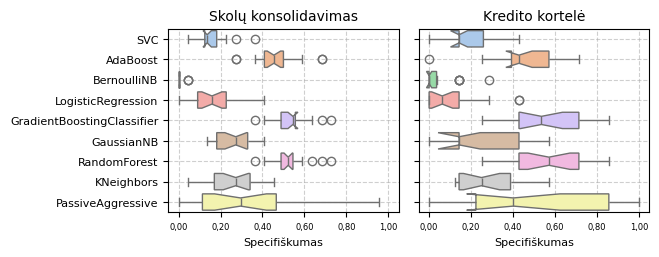

In [35]:
from matplotlib.ticker import FuncFormatter

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

def comma_formatter(x, pos):
    return f"{x:.2f}".replace('.', ',')

df_debt = pd.DataFrame({
    'Modelis': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Specifiškumas': np.concatenate([scores_svc_debt_subset, scores_AdaBoost_debt_subset, scores_BernoulliNB_debt_subset, scores_lr_debt_subset, scores_gb_debt_subset, scores_gnb_debt_subset, scores_rf_debt_subset, scores_knn_debt_subset, scores_pa_debt_subset])
})

df_credit = pd.DataFrame({
    'Modelis': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Specifiškumas': np.concatenate([scores_svc_credit_subset, scores_AdaBoost_credit_subset, scores_BernoulliNB_credit_subset, scores_lr_credit_subset, scores_gb_credit_subset, scores_gnb_credit_subset, scores_rf_credit_subset, scores_knn_credit_subset, scores_pa_credit_subset])
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_inch, height_inch), sharey=True, sharex=True)

sns.boxplot(y='Modelis', x='Specifiškumas', data=df_debt, notch=True, palette="pastel", hue='Modelis', ax=ax1, legend=False)
ax1.set_title("Skolų konsolidavimas", fontsize=10)
ax1.set_ylabel("", fontsize=8)
ax1.set_xlabel("Specifiškumas", fontsize=8)
ax1.tick_params(axis='y', labelsize=8)
ax1.tick_params(axis='x', labelsize=6)
ax1.xaxis.set_major_formatter(FuncFormatter(comma_formatter))
ax1.grid(True, linestyle='--', alpha=0.6)

sns.boxplot(y='Modelis', x='Specifiškumas', data=df_credit, notch=True, palette="pastel", hue='Modelis', ax=ax2, legend=False)
ax2.set_title("Kredito kortelė", fontsize=10)
ax2.set_ylabel("", fontsize=8) 
ax2.set_xlabel("Specifiškumas", fontsize=8)
# ax2.tick_params(axis='y', which='both', left=False)
ax2.tick_params(axis='x', labelsize=6)
ax2.xaxis.set_major_formatter(FuncFormatter(comma_formatter))
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig("klasifikatoriai_palyginimas.png", dpi=300, bbox_inches='tight')
plt.show()

## Ismoketa, visi pozymiai, specifiskumas

In [36]:
debt_data_paid = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data_paid = debt_data_paid.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'credit.policy'])
debt_data_paid.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,26.40,697,3840.000000,5132,41.4,2,0,0,0,45000.000056
2157,13.02,687,2130.000000,9451,33.3,4,0,0,1,37499.999927
2158,19.52,672,4529.958333,8443,33.2,4,1,0,0,38000.000049
2159,16.19,672,6360.000000,5494,83.2,4,0,0,0,60999.999808
2160,26.52,667,2672.958333,21300,65.5,4,0,0,0,55199.999875


In [37]:
credit_data_paid = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data_paid = credit_data_paid.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'credit.policy'])
credit_data_paid.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,16.87,677,3779.958333,2488,62.2,5,0,0,0,34999.999983
1400,15.14,647,3299.000000,36662,82.9,0,0,0,0,49999.999779
1401,4.51,727,600.000000,669,7.0,0,0,0,0,49999.999779
1402,6.24,657,2490.000000,8558,80.7,3,0,0,0,71000.000282
1403,12.26,702,6960.000000,56200,57.4,4,0,0,0,159999.999325


In [38]:
X_debt_paid = debt_data_paid.drop(['not.fully.paid'], axis=1)
y_debt_paid = debt_data_paid['not.fully.paid']

X_credit_paid = credit_data_paid.drop(['not.fully.paid'], axis=1)
y_credit_paid= credit_data_paid['not.fully.paid']

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Konsolidavimo (Specifiškumas): 1.0000
Kredito kortelės (Specifiškumas): 1.0000
Konsolidavimo (Specifiškumas): 0.9990
Kredito kortelės (Specifiškumas): 0.9939
Konsolidavimo (Specifiškumas): 1.0000
Kredito kortelės (Specifiškumas): 0.9955
Konsolidavimo (Specifiškumas): 0.9995
Kredito kortelės (Specifiškumas): 0.9970
Konsolidavimo (Specifiškumas): 0.9921
Kredito kortelės (Specifiškumas): 0.9818
Konsolidavimo (Specifiškumas): 0.9062
Kredito kortelės (Specifiškumas): 0.9470
Konsolidavimo (Specifiškumas): 0.9961
Kredito kortelės (Specifiškumas): 0.9909
Konsolidavimo (Specifiškumas): 0.9704
Kredito kortelės (Specifiškumas): 0.9909
Konsolidavimo (Specifiškumas): 0.9012
Kredito kortelės (Specifiškumas): 0.9409


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packag

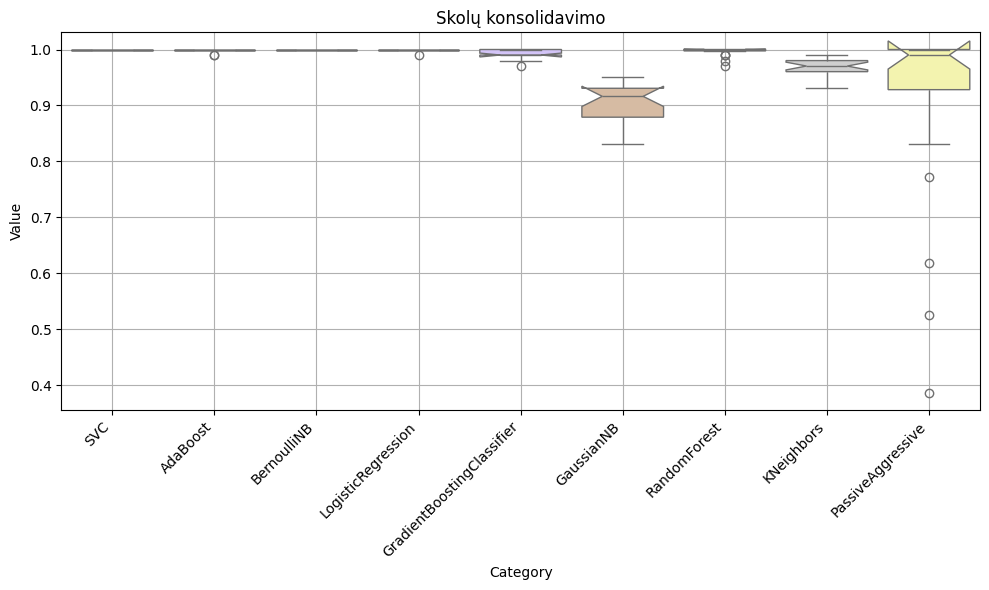

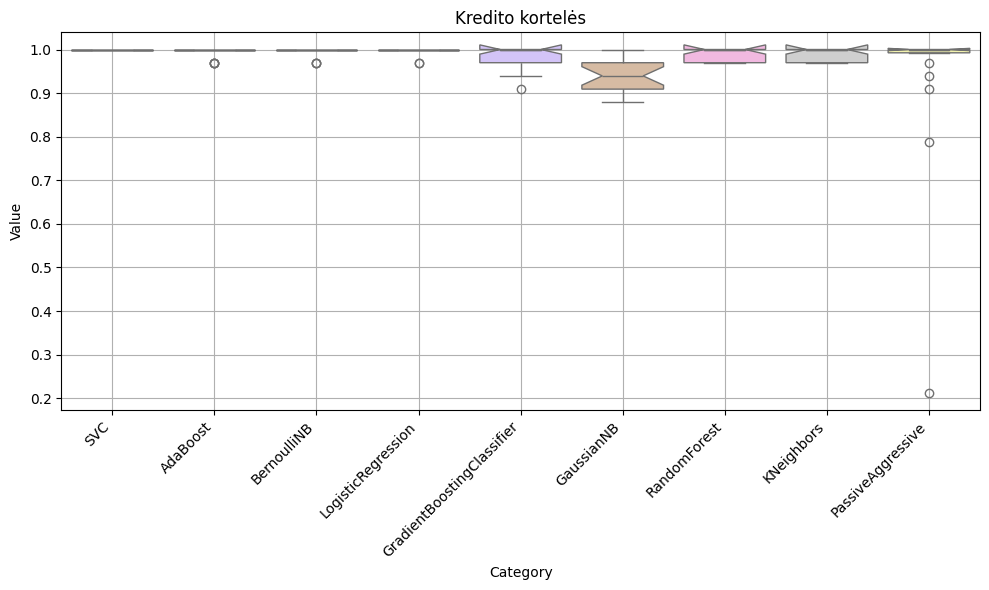

In [39]:
svc_pipeline = make_pipeline(MinMaxScaler(), svm.SVC())
AdaBoost_pipeline = make_pipeline(MinMaxScaler(), AdaBoost())
BernoulliNB_pipeline = make_pipeline(MinMaxScaler(), BernoulliNB())
lr_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression())
gb_pipeline = make_pipeline(MinMaxScaler(), GradientBoostingClassifier())
gnb_pipeline = make_pipeline(MinMaxScaler(), GaussianNB())
rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier())
knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier())
pa_pipeline = make_pipeline(MinMaxScaler(), PassiveAggressiveClassifier())

scores_svc_debt_paid = cross_val_score(svc_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_svc_debt_paid.mean():.4f}")

scores_svc_credit_paid = cross_val_score(svc_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_svc_credit_paid.mean():.4f}")

scores_AdaBoost_debt_paid = cross_val_score(AdaBoost_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_AdaBoost_debt_paid.mean():.4f}")

scores_AdaBoost_credit_paid = cross_val_score(AdaBoost_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_AdaBoost_credit_paid.mean():.4f}")

scores_BernoulliNB_debt_paid = cross_val_score(BernoulliNB_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_BernoulliNB_debt_paid.mean():.4f}")

scores_BernoulliNB_credit_paid = cross_val_score(BernoulliNB_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_BernoulliNB_credit_paid.mean():.4f}")

scores_lr_debt_paid = cross_val_score(lr_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_lr_debt_paid.mean():.4f}")

scores_lr_credit_paid = cross_val_score(lr_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_lr_credit_paid.mean():.4f}")

scores_gb_debt_paid = cross_val_score(gb_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gb_debt_paid.mean():.4f}")

scores_gb_credit_paid = cross_val_score(gb_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gb_credit_paid.mean():.4f}")

scores_gnb_debt_paid = cross_val_score(gnb_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gnb_debt_paid.mean():.4f}")

scores_gnb_credit_paid = cross_val_score(gnb_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gnb_credit_paid.mean():.4f}")

scores_rf_debt_paid = cross_val_score(rf_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_rf_debt_paid.mean():.4f}")

scores_rf_credit_paid = cross_val_score(rf_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_rf_credit_paid.mean():.4f}")

scores_knn_debt_paid = cross_val_score(knn_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_knn_debt_paid.mean():.4f}")

scores_knn_credit_paid = cross_val_score(knn_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_knn_credit_paid.mean():.4f}")

scores_pa_debt_paid = cross_val_score(pa_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_pa_debt_paid.mean():.4f}")

scores_pa_credit_paid = cross_val_score(pa_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_pa_credit_paid.mean():.4f}")

df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_debt_paid, scores_AdaBoost_debt_paid, scores_BernoulliNB_debt_paid, scores_lr_debt_paid, scores_gb_debt_paid, scores_gnb_debt_paid, scores_rf_debt_paid, scores_knn_debt_paid, scores_pa_debt_paid])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_credit_paid, scores_AdaBoost_credit_paid, scores_BernoulliNB_credit_paid, scores_lr_credit_paid, scores_gb_credit_paid, scores_gnb_credit_paid, scores_rf_credit_paid, scores_knn_credit_paid, scores_pa_credit_paid])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

-----

# Mokymo ir testavimo aibė

In [10]:
debt_data = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data = debt_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'inq.last.6mths'])
debt_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,0,26.40,697,3840.000000,5132,41.4,0,0,0,45000.000056
2157,0,13.02,687,2130.000000,9451,33.3,0,0,1,37499.999927
2158,0,19.52,672,4529.958333,8443,33.2,1,0,0,38000.000049
2159,0,16.19,672,6360.000000,5494,83.2,0,0,0,60999.999808
2160,0,26.52,667,2672.958333,21300,65.5,0,0,0,55199.999875


In [11]:
credit_data = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data = credit_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'inq.last.6mths'])
credit_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,0,16.87,677,3779.958333,2488,62.2,0,0,0,34999.999983
1400,0,15.14,647,3299.000000,36662,82.9,0,0,0,49999.999779
1401,0,4.51,727,600.000000,669,7.0,0,0,0,49999.999779
1402,0,6.24,657,2490.000000,8558,80.7,0,0,0,71000.000282
1403,0,12.26,702,6960.000000,56200,57.4,0,0,0,159999.999325


In [12]:
X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.drop(columns=['not.fully.paid', 'credit.policy']), debt_data['credit.policy'], test_size=0.2, random_state=123, stratify=debt_data['credit.policy'])

X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.drop(columns=['not.fully.paid', 'credit.policy']), credit_data['credit.policy'], test_size=0.2, random_state=123, stratify=credit_data['credit.policy'])

In [13]:
X_train_debt

,dti,fico,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,annual.inc
3416,24.40,697,4201.958333,19525,59.0,0,0,63000.000291
2564,21.90,652,6180.000000,13025,28.4,0,0,39999.999876
2754,6.26,702,5249.958333,1783,59.4,0,0,78000.000338
3993,9.87,707,1560.000000,12323,44.0,0,0,36000.000092
4398,2.71,767,3870.041667,0,0.0,0,0,54999.999768
...,...,...,...,...,...,...,...,...
2778,13.26,692,3630.000000,6172,22.2,0,0,39999.999876
3615,2.38,797,5400.000000,4650,14.1,0,0,48000.000005
2943,7.90,747,2759.958333,5418,8.2,0,0,61193.600130
2278,20.96,657,6360.041667,24391,98.4,2,0,82000.000308


In [14]:
X_train_debt.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,annual.inc
3416,24.40,697,4201.958333,19525,59.0,0,0,63000.000291
2564,21.90,652,6180.000000,13025,28.4,0,0,39999.999876
2754,6.26,702,5249.958333,1783,59.4,0,0,78000.000338
3993,9.87,707,1560.000000,12323,44.0,0,0,36000.000092
4398,2.71,767,3870.041667,0,0.0,0,0,54999.999768


# Min-Max normalizavimas

In [15]:
min_max_scaler = MinMaxScaler()

X_debt_norm = min_max_scaler.fit_transform(debt_data.drop(columns=['not.fully.paid', 'credit.policy']))
X_train_debt_norm = min_max_scaler.fit_transform(X_train_debt)
X_test_debt_norm = min_max_scaler.transform(X_test_debt)

X_credit_norm = min_max_scaler.fit_transform(credit_data.drop(columns=['not.fully.paid', 'credit.policy']))
X_train_credit_norm = min_max_scaler.fit_transform(X_train_credit)
X_test_credit_norm = min_max_scaler.transform(X_test_credit)

# Dimensijos mažinimas

In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)

X_debt_tsne = tsne.fit_transform(X_debt_norm)
X_credit_tsne = tsne.fit_transform(X_credit_norm)

# debt_data['tsne_1'] = X_debt_tsne[:, 0]
# debt_data['tsne_2'] = X_debt_tsne[:, 1]

# credit_data['tsne_1'] = X_credit_tsne[:, 0]
# credit_data['tsne_2'] = X_credit_tsne[:, 1]

In [17]:
X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne = train_test_split(X_debt_tsne, debt_data['credit.policy'], test_size=0.2, random_state=123, stratify=debt_data['credit.policy'])
X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne = train_test_split(X_credit_tsne, credit_data['credit.policy'], test_size=0.2, random_state=123, stratify=credit_data['credit.policy'])

# X_train, X_test, y_train, y_test = train_test_split(
#     X_debt_norm, debt_data['credit.policy'], test_size=0.2, random_state=123
# )

# X_train_tsne, X_test_tsne = train_test_split(
#     debt_data[['tsne_1', 'tsne_2']], test_size=0.2, random_state=123
# )

# Parametrų atrinkimas

In [18]:
specificity_scorer = make_scorer(recall_score, pos_label=0)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

## AdaBoost: Origiinali dimensija
### Skolų konsolidavimo grupė

In [125]:
AdaModel_default = AdaBoost(random_state = 42)
AdaModel_default.fit(X_train_debt_norm, y_train_debt)

y_pred = AdaModel_default.predict(X_test_debt_norm)

cm = confusion_matrix(y_test_debt, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8968
Specifiškumas (Specificity): 0.4659

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.953488  0.465909  0.625954  0.518987
Klasė 1   0.891204  0.994832  0.940171  0.972222


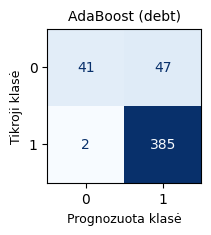

In [126]:
y_pred_debt = AdaModel_default.predict(X_test_debt_norm)

cm = confusion_matrix(y_test_debt, y_pred_debt)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (debt)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("adaboost_debt_cm_origin.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\4121688370.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\4121688370.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


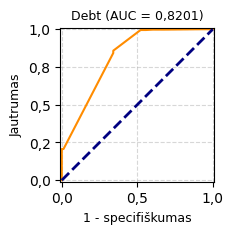

In [127]:
y_probs = AdaModel_default.predict_proba(X_test_debt_norm)[:, 1]
auc_score = roc_auc_score(y_test_debt, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    AdaModel_default, 
    X_test_debt_norm, 
    y_test_debt, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("adaboost_debt_roc_origin.png", dpi=300, bbox_inches='tight')
plt.show()

In [128]:
AdaModel = AdaBoost(random_state = 42)

param_grid = {
    'n_estimators': [356],
    'learning_rate': [1.8]
}

grid_search_debt = GridSearchCV(
    estimator=AdaModel,
    param_grid=param_grid,
    cv=5,
    scoring=specificity_scorer,
    n_jobs=-1
)

grid_search_debt.fit(X_train_debt_norm, y_train_debt)

# X_test_debt_norm

print(grid_search_debt.best_params_)
print(grid_search_debt.best_score_)
best_adaBoost_debt = grid_search_debt.best_estimator_
print(best_adaBoost_debt.score(X_test_debt_norm, y_test_debt))

{'learning_rate': 1.8, 'n_estimators': 356}
0.54261569416499
0.8926315789473684


In [129]:
AdaModel = AdaBoost(random_state = 42, learning_rate=1.8)

param_range = np.arange(5, 365, 5)
param_name = "n_estimators"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_debt_norm, y_train_debt, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

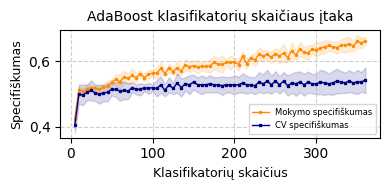

In [130]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost klasifikatorių skaičiaus įtaka", fontsize=10)
plt.xlabel("Klasifikatorių skaičius", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.savefig("adaboost_debt_param_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [131]:
AdaModel = AdaBoost(random_state = 42, n_estimators=356)

param_range = np.arange(0.5, 2, 0.05)
param_name = "learning_rate"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_debt_norm, y_train_debt, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

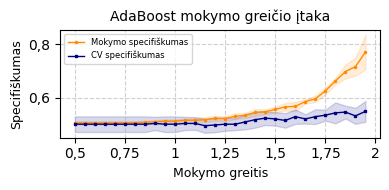

In [132]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost mokymo greičio įtaka", fontsize=10)
plt.xlabel("Mokymo greitis", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper left", fontsize=6)

plt.tight_layout()
plt.savefig("adaboost_debt_param_lr.png", dpi=300, bbox_inches='tight')
plt.show()

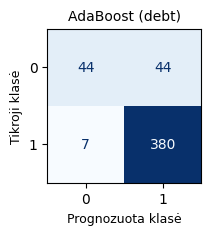

In [133]:
y_pred_debt = best_adaBoost_debt.predict(X_test_debt_norm)

cm = confusion_matrix(y_test_debt, y_pred_debt)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (debt)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("adaboost_debt_cm.png", dpi=300, bbox_inches='tight')
plt.show()

In [134]:
y_pred = best_adaBoost_debt.predict(X_test_debt_norm)

cm = confusion_matrix(y_test_debt, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8926
Specifiškumas (Specificity): 0.5000

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.862745  0.500000  0.633094  0.545906
Klasė 1   0.896226  0.981912  0.937115  0.963489


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\3358128849.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\3358128849.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


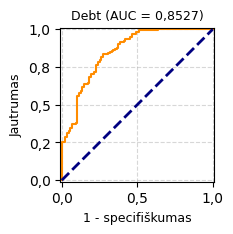

In [135]:
y_probs = best_adaBoost_debt.predict_proba(X_test_debt_norm)[:, 1]
auc_score = roc_auc_score(y_test_debt, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_debt, 
    X_test_debt_norm, 
    y_test_debt, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("adaboost_debt_roc.png", dpi=300, bbox_inches='tight')
plt.show()

In [136]:
y_pred_debt = best_adaBoost_debt.predict(X_test_debt_norm)

tn, fp, fn, tp = confusion_matrix(y_test_debt, y_pred_debt).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

youden_index = sensitivity + specificity - 1

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Youden Index: {youden_index:.4f}")

Sensitivity: 0.9819
Specificity: 0.5000
Youden Index: 0.4819


In [137]:
y_probs_debt = best_adaBoost_debt.predict_proba(X_test_debt_norm)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_debt, y_probs_debt)
youden_scores = tpr - fpr
best_idx = np.argmax(youden_scores)
best_threshold = thresholds[best_idx]
print(f"Optimalus slenkstis (Youden): {best_threshold:.4f}")
y_pred_debt = (y_probs_debt >= best_threshold).astype(int)

Optimalus slenkstis (Youden): 0.5084


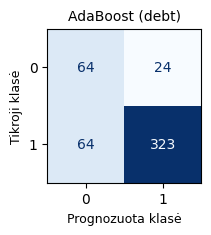

In [138]:
cm = confusion_matrix(y_test_debt, y_pred_debt)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (debt)', fontsize=10)
plt.xlabel('Prognozuota klasė', fontsize=9)
plt.ylabel('Tikroji klasė', fontsize=9)
plt.savefig("adaboost_debt_cm_youden.png", dpi=300, bbox_inches='tight')
plt.show()

In [139]:
cm = confusion_matrix(y_test_debt, y_pred_debt)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

youden_index = recall[1] + specificity_val - 1  # sensitivity + specificity - 1

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print(f"Youden indeksas: {youden_index:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8147
Specifiškumas (Specificity): 0.7273
Youden indeksas: 0.5619

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.500000  0.727273  0.592593  0.666667
Klasė 1   0.930836  0.834625  0.880109  0.852243


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1497992947.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1497992947.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


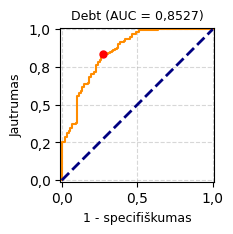

In [140]:
auc_score = roc_auc_score(y_test_debt, y_probs_debt)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_debt, 
    X_test_debt_norm, 
    y_test_debt, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Youden taškas
ax.plot(
    fpr[best_idx], tpr[best_idx],
    marker='o', markersize=5,
    color='red', zorder=5
)

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize=9)
plt.ylabel('Jautrumas', fontsize=9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("adaboost_debt_roc_youden.png", dpi=300, bbox_inches='tight')
plt.show()

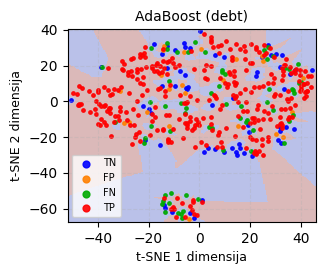

In [141]:
x_coords = X_test_debt_tsne[:, 0]
y_coords = X_test_debt_tsne[:, 1]

y_pred_youden = (best_adaBoost_debt.predict_proba(X_test_debt_norm)[:, 1] >= best_threshold).astype(int)

xi = np.linspace(x_coords.min()-1, x_coords.max()+1, 200)
yi = np.linspace(y_coords.min()-1, y_coords.max()+1, 200)
xx, yy = np.meshgrid(xi, yi)

grid_z = griddata((x_coords, y_coords), y_pred_youden, (xx, yy), method='nearest')

plt.figure(figsize=(3.2, 2.5))
cmap_light = ListedColormap(["#7684D4", "#B97474"])
plt.pcolormesh(xx, yy, grid_z, cmap=cmap_light, shading='auto', alpha=0.5)

y_true = np.array(y_test_debt)

categories = {
    'TN': (y_true == 0) & (y_pred_youden == 0),
    'FP': (y_true == 0) & (y_pred_youden == 1),
    'FN': (y_true == 1) & (y_pred_youden == 0),
    'TP': (y_true == 1) & (y_pred_youden == 1),
}

colors = {'TN': '#0000FF', 'FP': '#FF8000', 'FN': '#00AA00', 'TP': '#FF0000'}

for label, mask in categories.items():
    plt.scatter(x_coords[mask], y_coords[mask], c=colors[label],
                label=label, s=6, alpha=0.9)

plt.title("AdaBoost (debt)", fontsize=10)
plt.xlabel("t-SNE 1 dimensija", fontsize=9)
plt.ylabel("t-SNE 2 dimensija", fontsize=9)
plt.legend(fontsize=7, markerscale=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("adaboost_debt_db.png", dpi=300, bbox_inches='tight')
plt.show()

### Kredito kortelės grupė

In [142]:
AdaModel_default = AdaBoost(random_state = 42)
AdaModel_default.fit(X_train_credit_norm, y_train_credit)

y_pred = AdaModel_default.predict(X_test_credit_norm)

cm = confusion_matrix(y_test_credit, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8487
Specifiškumas (Specificity): 0.4138

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.666667  0.413793  0.510638  0.447761
Klasė 1   0.873134  0.951220  0.910506  0.934505


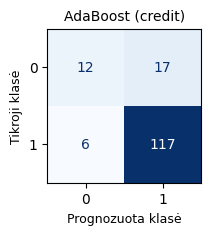

In [143]:
y_pred_credit = AdaModel_default.predict(X_test_credit_norm)

cm = confusion_matrix(y_test_credit, y_pred_credit)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (credit)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("adaboost_credit_cm_origin.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1945153779.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1945153779.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


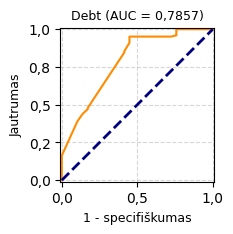

In [144]:
y_probs = AdaModel_default.predict_proba(X_test_credit_norm)[:, 1]
auc_score = roc_auc_score(y_test_credit, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    AdaModel_default, 
    X_test_credit_norm, 
    y_test_credit, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("adaboost_credit_roc_origin.png", dpi=300, bbox_inches='tight')
plt.show()

In [145]:
AdaModel = AdaBoost(random_state = 42)

param_grid = {
    'n_estimators': [290],
    'learning_rate': [1.5]
}

grid_search_credit = GridSearchCV(
    estimator=AdaModel,
    param_grid=param_grid,
    cv=5,
    scoring=specificity_scorer,
    n_jobs=-1
)

grid_search_credit.fit(X_train_credit_norm, y_train_credit)

print(grid_search_credit.best_params_)
print(grid_search_credit.best_score_)
best_adaBoost_credit = grid_search_credit.best_estimator_
print(best_adaBoost_credit.score(X_test_credit_norm, y_test_credit))

{'learning_rate': 1.5, 'n_estimators': 290}
0.6297101449275362
0.8618421052631579


In [146]:
AdaModel = AdaBoost(random_state = 42, learning_rate=1.5)

param_range = np.arange(5, 365, 5)
param_name = "n_estimators"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_credit_norm, y_train_credit, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

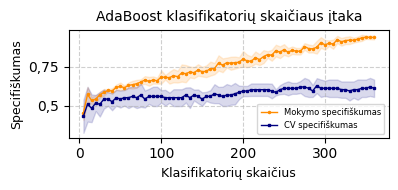

In [147]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost klasifikatorių skaičiaus įtaka", fontsize=10)
plt.xlabel("Klasifikatorių skaičius", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.savefig("adaboost_credit_param_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [148]:
AdaModel = AdaBoost(random_state = 42, n_estimators=290)

param_range = np.arange(0.5, 2, 0.05)
param_name = "learning_rate"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_credit_norm, y_train_credit, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

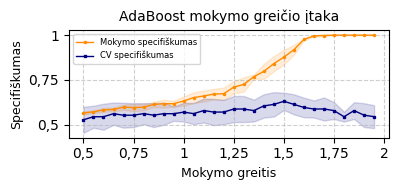

In [149]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost mokymo greičio įtaka", fontsize=10)
plt.xlabel("Mokymo greitis", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper left", fontsize=6)

plt.tight_layout()
plt.savefig("adaboost_credit_param_lr.png", dpi=300, bbox_inches='tight')
plt.show()

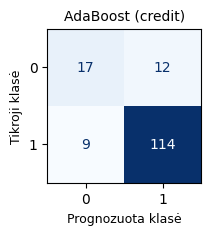

In [150]:
y_pred_credit = best_adaBoost_credit.predict(X_test_credit_norm)

cm = confusion_matrix(y_test_credit, y_pred_credit)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (credit)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("adaboost_credit_cm.png", dpi=300, bbox_inches='tight')
plt.show()

In [151]:
y_pred = best_adaBoost_credit.predict(X_test_credit_norm)

cm = confusion_matrix(y_test_credit, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8618
Specifiškumas (Specificity): 0.5862

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.653846  0.586207  0.618182  0.598592
Klasė 1   0.904762  0.926829  0.915663  0.922330


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1733954402.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1733954402.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


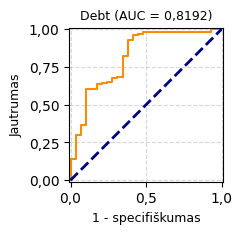

In [152]:
y_probs = best_adaBoost_credit.predict_proba(X_test_credit_norm)[:, 1]
auc_score = roc_auc_score(y_test_credit, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_credit, 
    X_test_credit_norm, 
    y_test_credit, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("adaboost_credit_roc.png", dpi=300, bbox_inches='tight')
plt.show()

In [153]:
y_pred_credit = best_adaBoost_credit.predict(X_test_credit_norm)

tn, fp, fn, tp = confusion_matrix(y_test_credit, y_pred_credit).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

youden_index = sensitivity + specificity - 1

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Youden Index: {youden_index:.4f}")

Sensitivity: 0.9268
Specificity: 0.5862
Youden Index: 0.5130


In [154]:
y_probs_credit = best_adaBoost_debt.predict_proba(X_test_credit_norm)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_credit, y_probs_credit)
youden_scores = tpr - fpr
best_idx = np.argmax(youden_scores)
best_threshold = thresholds[best_idx]
print(f"Optimalus slenkstis (Youden): {best_threshold:.4f}")
y_pred_credit = (y_probs_credit >= best_threshold).astype(int)

Optimalus slenkstis (Youden): 0.4994


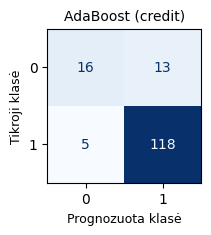

In [155]:
cm = confusion_matrix(y_test_credit, y_pred_credit)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (credit)', fontsize=10)
plt.xlabel('Prognozuota klasė', fontsize=9)
plt.ylabel('Tikroji klasė', fontsize=9)
plt.savefig("adaboost_credit_cm_youden.png", dpi=300, bbox_inches='tight')
plt.show()

In [156]:
cm = confusion_matrix(y_test_credit, y_pred_credit)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

youden_index = recall[1] + specificity_val - 1  # sensitivity + specificity - 1

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print(f"Youden indeksas: {youden_index:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8816
Specifiškumas (Specificity): 0.5517
Youden indeksas: 0.5111

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.761905  0.551724  0.640000  0.583942
Klasė 1   0.900763  0.959350  0.929134  0.947030


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\2283266292.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\2283266292.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


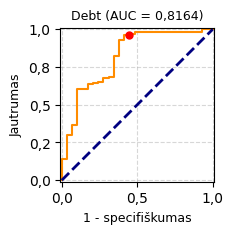

In [157]:
auc_score = roc_auc_score(y_test_credit, y_probs_credit)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_credit, 
    X_test_credit_norm, 
    y_test_credit, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Youden taškas
ax.plot(
    fpr[best_idx], tpr[best_idx],
    marker='o', markersize=5,
    color='red', zorder=5
)

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize=9)
plt.ylabel('Jautrumas', fontsize=9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("adaboost_credit_roc_youden.png", dpi=300, bbox_inches='tight')
plt.show()

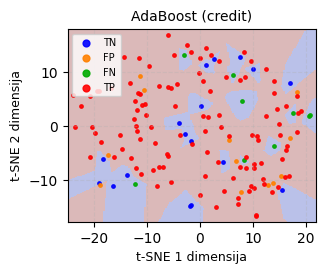

In [158]:
x_coords = X_test_credit_tsne[:, 0]
y_coords = X_test_credit_tsne[:, 1]

y_pred_youden = (best_adaBoost_credit.predict_proba(X_test_credit_norm)[:, 1] >= best_threshold).astype(int)

xi = np.linspace(x_coords.min()-1, x_coords.max()+1, 200)
yi = np.linspace(y_coords.min()-1, y_coords.max()+1, 200)
xx, yy = np.meshgrid(xi, yi)

grid_z = griddata((x_coords, y_coords), y_pred_youden, (xx, yy), method='nearest')

plt.figure(figsize=(3.2, 2.5))
cmap_light = ListedColormap(["#7684D4", "#B97474"])
plt.pcolormesh(xx, yy, grid_z, cmap=cmap_light, shading='auto', alpha=0.5)

y_true = np.array(y_test_credit)

categories = {
    'TN': (y_true == 0) & (y_pred_youden == 0),
    'FP': (y_true == 0) & (y_pred_youden == 1),
    'FN': (y_true == 1) & (y_pred_youden == 0),
    'TP': (y_true == 1) & (y_pred_youden == 1),
}

colors = {'TN': '#0000FF', 'FP': '#FF8000', 'FN': '#00AA00', 'TP': '#FF0000'}

for label, mask in categories.items():
    plt.scatter(x_coords[mask], y_coords[mask], c=colors[label],
                label=label, s=6, alpha=0.9)

plt.title("AdaBoost (credit)", fontsize=10)
plt.xlabel("t-SNE 1 dimensija", fontsize=9)
plt.ylabel("t-SNE 2 dimensija", fontsize=9)
plt.legend(fontsize=7, markerscale=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("adaboost_credit_db.png", dpi=300, bbox_inches='tight')
plt.show()

## AdaBoost: t-SNE duomenys
### Skolų konsolidavimo grupė

In [159]:
AdaModel_default = AdaBoost(random_state = 42)
AdaModel_default.fit(X_train_debt_tsne, y_train_debt_tsne)

y_pred = AdaModel_default.predict(X_test_debt_tsne)

cm = confusion_matrix(y_test_debt_tsne, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.8147
Specifiškumas (Specificity): 0.0000

Matai atskiroms klasėms:
         Precision  Recall        F1      F2
Klasė 0        NaN     0.0       NaN     NaN
Klasė 1   0.814737     1.0  0.897912  0.9565


C:\Users\crist\AppData\Local\Temp\ipykernel_35204\3800100801.py:15: RuntimeWarning: invalid value encountered in divide
  precision = diag / colsums


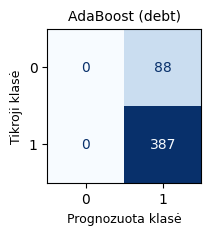

In [160]:
y_pred_debt = AdaModel_default.predict(X_test_debt_tsne)

cm = confusion_matrix(y_test_debt_tsne, y_pred_debt)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (debt)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("tsne_adaboost_debt_cm_origin.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\2803784360.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\2803784360.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


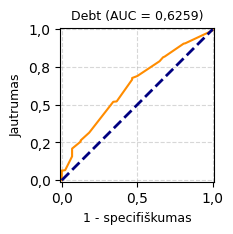

In [161]:
y_probs = AdaModel_default.predict_proba(X_test_debt_tsne)[:, 1]
auc_score = roc_auc_score(y_test_debt_tsne, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    AdaModel_default, 
    X_test_debt_tsne, 
    y_test_debt_tsne, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_adaboost_debt_roc_origin.png", dpi=300, bbox_inches='tight')
plt.show()

In [162]:
AdaModel = AdaBoost(random_state = 42)

param_grid = {
    'n_estimators': [356],
    'learning_rate': [1.8]
}

grid_search_debt = GridSearchCV(
    estimator=AdaModel,
    param_grid=param_grid,
    cv=5,
    scoring=specificity_scorer,
    n_jobs=-1
)

grid_search_debt.fit(X_train_debt_tsne, y_train_debt_tsne)

# X_test_debt_norm

print(grid_search_debt.best_params_)
print(grid_search_debt.best_score_)
best_adaBoost_debt = grid_search_debt.best_estimator_
print(best_adaBoost_debt.score(X_test_debt_tsne, y_test_debt_tsne))

{'learning_rate': 1.8, 'n_estimators': 356}
0.09388329979879276
0.7957894736842105


In [163]:
AdaModel = AdaBoost(random_state = 42, learning_rate=1.8)

param_range = np.arange(5, 365, 5)
param_name = "n_estimators"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_debt_tsne, y_train_debt_tsne, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

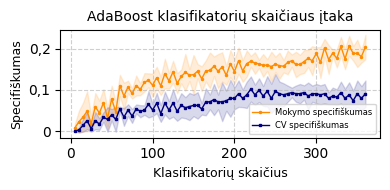

In [164]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost klasifikatorių skaičiaus įtaka", fontsize=10)
plt.xlabel("Klasifikatorių skaičius", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.savefig("tsne_adaboost_debt_param_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [165]:
AdaModel = AdaBoost(random_state = 42, n_estimators=356)

param_range = np.arange(0.5, 2, 0.05)
param_name = "learning_rate"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_debt_tsne, y_train_debt_tsne, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

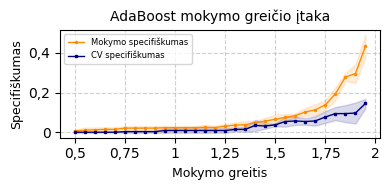

In [166]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost mokymo greičio įtaka", fontsize=10)
plt.xlabel("Mokymo greitis", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper left", fontsize=6)

plt.tight_layout()
plt.savefig("tsne_adaboost_debt_param_lr.png", dpi=300, bbox_inches='tight')
plt.show()

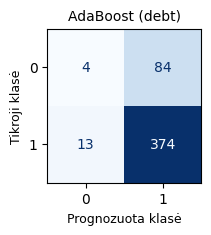

In [167]:
y_pred_debt = best_adaBoost_debt.predict(X_test_debt_tsne)

cm = confusion_matrix(y_test_debt_tsne, y_pred_debt)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (debt)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("tsne_adaboost_debt_cm.png", dpi=300, bbox_inches='tight')
plt.show()

In [168]:
y_pred = best_adaBoost_debt.predict(X_test_debt_tsne)

cm = confusion_matrix(y_test_debt_tsne, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.7958
Specifiškumas (Specificity): 0.0455

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.235294  0.045455  0.076190  0.054201
Klasė 1   0.816594  0.966408  0.885207  0.932203


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1428651166.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1428651166.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


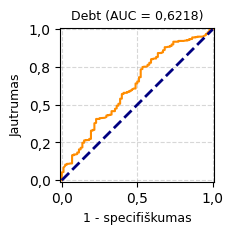

In [169]:
y_probs = best_adaBoost_debt.predict_proba(X_test_debt_tsne)[:, 1]
auc_score = roc_auc_score(y_test_debt_tsne, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_debt, 
    X_test_debt_tsne, 
    y_test_debt_tsne, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_adaboost_debt_roc.png", dpi=300, bbox_inches='tight')
plt.show()

In [170]:
y_pred_debt = best_adaBoost_debt.predict(X_test_debt_tsne)

tn, fp, fn, tp = confusion_matrix(y_test_debt_tsne, y_pred_debt).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

youden_index = sensitivity + specificity - 1

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Youden Index: {youden_index:.4f}")

Sensitivity: 0.9664
Specificity: 0.0455
Youden Index: 0.0119


In [171]:
y_probs_debt = best_adaBoost_debt.predict_proba(X_test_debt_tsne)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_debt_tsne, y_probs_debt)
youden_scores = tpr - fpr
best_idx = np.argmax(youden_scores)
best_threshold = thresholds[best_idx]
print(f"Optimalus slenkstis (Youden): {best_threshold:.4f}")
y_pred_debt = (y_probs_debt >= best_threshold).astype(int)

Optimalus slenkstis (Youden): 0.5083


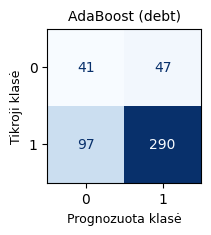

In [172]:
cm = confusion_matrix(y_test_debt_tsne, y_pred_debt)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (debt)', fontsize=10)
plt.xlabel('Prognozuota klasė', fontsize=9)
plt.ylabel('Tikroji klasė', fontsize=9)
plt.savefig("tsne_adaboost_debt_cm_youden.png", dpi=300, bbox_inches='tight')
plt.show()

In [173]:
cm = confusion_matrix(y_test_debt_tsne, y_pred_debt)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

youden_index = recall[1] + specificity_val - 1  # sensitivity + specificity - 1

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print(f"Youden indeksas: {youden_index:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.6968
Specifiškumas (Specificity): 0.4659
Youden indeksas: 0.2153

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.297101  0.465909  0.362832  0.418367
Klasė 1   0.860534  0.749354  0.801105  0.769231


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\4081166251.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\4081166251.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


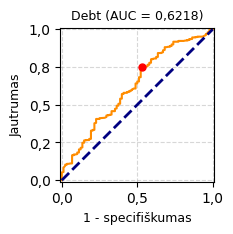

In [174]:
auc_score = roc_auc_score(y_test_debt_tsne, y_probs_debt)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_debt, 
    X_test_debt_tsne, 
    y_test_debt_tsne, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Youden taškas
ax.plot(
    fpr[best_idx], tpr[best_idx],
    marker='o', markersize=5,
    color='red', zorder=5
)

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize=9)
plt.ylabel('Jautrumas', fontsize=9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_adaboost_debt_roc_youden.png", dpi=300, bbox_inches='tight')
plt.show()

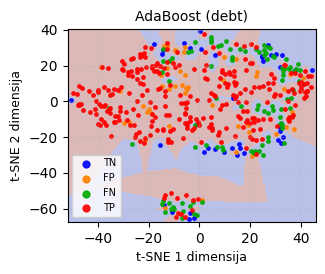

In [175]:
x_coords = X_test_debt_tsne[:, 0]
y_coords = X_test_debt_tsne[:, 1]

y_pred_youden = (best_adaBoost_debt.predict_proba(X_test_debt_tsne)[:, 1] >= best_threshold).astype(int)

xi = np.linspace(x_coords.min()-1, x_coords.max()+1, 200)
yi = np.linspace(y_coords.min()-1, y_coords.max()+1, 200)
xx, yy = np.meshgrid(xi, yi)

grid_z = griddata((x_coords, y_coords), y_pred_youden, (xx, yy), method='nearest')

plt.figure(figsize=(3.2, 2.5))
cmap_light = ListedColormap(["#7684D4", "#B97474"])
plt.pcolormesh(xx, yy, grid_z, cmap=cmap_light, shading='auto', alpha=0.5)

y_true = np.array(y_test_debt)

categories = {
    'TN': (y_true == 0) & (y_pred_youden == 0),
    'FP': (y_true == 0) & (y_pred_youden == 1),
    'FN': (y_true == 1) & (y_pred_youden == 0),
    'TP': (y_true == 1) & (y_pred_youden == 1),
}

colors = {'TN': '#0000FF', 'FP': '#FF8000', 'FN': '#00AA00', 'TP': '#FF0000'}

for label, mask in categories.items():
    plt.scatter(x_coords[mask], y_coords[mask], c=colors[label],
                label=label, s=6, alpha=0.9)

plt.title("AdaBoost (debt)", fontsize=10)
plt.xlabel("t-SNE 1 dimensija", fontsize=9)
plt.ylabel("t-SNE 2 dimensija", fontsize=9)
plt.legend(fontsize=7, markerscale=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("tsne_adaboost_debt_db.png", dpi=300, bbox_inches='tight')
plt.show()

### Kredito koretelės grupė

In [176]:
AdaModel_default = AdaBoost(random_state = 42)
AdaModel_default.fit(X_train_credit_tsne, y_train_credit_tsne)

y_pred = AdaModel_default.predict(X_test_credit_tsne)

cm = confusion_matrix(y_test_credit_tsne, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.7829
Specifiškumas (Specificity): 0.0000

Matai atskiroms klasėms:
         Precision   Recall        F1        F2
Klasė 0   0.000000  0.00000       NaN       NaN
Klasė 1   0.804054  0.96748  0.878229  0.929688


C:\Users\crist\AppData\Local\Temp\ipykernel_35204\118896442.py:17: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\118896442.py:21: RuntimeWarning: invalid value encountered in divide
  f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)


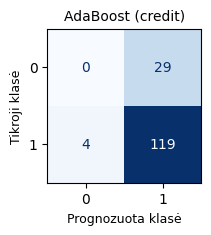

In [177]:
y_pred_credit = AdaModel_default.predict(X_test_credit_tsne)

cm = confusion_matrix(y_test_credit_tsne, y_pred_credit)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (credit)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("tsne_adaboost_credit_cm_origin.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\722666155.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\722666155.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


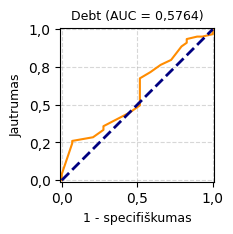

In [178]:
y_probs = AdaModel_default.predict_proba(X_test_credit_tsne)[:, 1]
auc_score = roc_auc_score(y_test_credit_tsne, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    AdaModel_default, 
    X_test_credit_tsne, 
    y_test_credit_tsne, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_adaboost_credit_roc_origin.png", dpi=300, bbox_inches='tight')
plt.show()

In [179]:
AdaModel = AdaBoost(random_state = 42)

param_grid = {
    'n_estimators': [284],
    'learning_rate': [1.8]
}

grid_search_credit = GridSearchCV(
    estimator=AdaModel,
    param_grid=param_grid,
    cv=5,
    scoring=specificity_scorer,
    n_jobs=-1
)

grid_search_credit.fit(X_train_credit_tsne, y_train_credit_tsne)

# X_test_debt_norm

print(grid_search_credit.best_params_)
print(grid_search_credit.best_score_)
best_adaBoost_credit = grid_search_credit.best_estimator_
print(best_adaBoost_credit.score(X_test_credit_tsne, y_test_credit_tsne))

{'learning_rate': 1.8, 'n_estimators': 284}
0.2670289855072464
0.7697368421052632


In [180]:
AdaModel = AdaBoost(random_state = 42, learning_rate=1.5)

param_range = np.arange(5, 365, 5)
param_name = "n_estimators"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_credit_tsne, y_train_credit_tsne, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

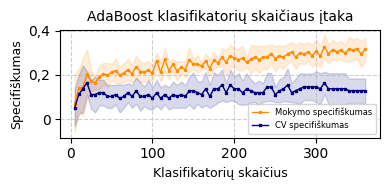

In [181]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost klasifikatorių skaičiaus įtaka", fontsize=10)
plt.xlabel("Klasifikatorių skaičius", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.savefig("tsne_adaboost_credit_param_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [182]:
AdaModel = AdaBoost(random_state = 42, n_estimators=290)

param_range = np.arange(0.5, 2, 0.05)
param_name = "learning_rate"

train_scores, val_scores = validation_curve(
    AdaModel, 
    X_train_credit_tsne, y_train_credit_tsne, 
    param_name=param_name, 
    param_range=param_range,
    cv=5, 
    scoring=specificity_scorer, 
    n_jobs=-1
)

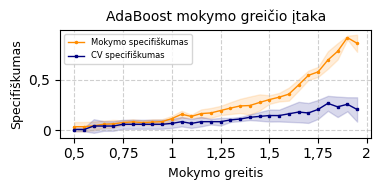

In [183]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(4, 2))

plt.plot(param_range, train_mean, label="Mokymo specifiškumas", 
         color="darkorange", lw=1, marker='o', markersize=1.5)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color="darkorange")

plt.plot(param_range, val_mean, label="CV specifiškumas",
         color="navy", lw=1, marker='s', markersize=1.5)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color="navy")

ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, pos: f"{x:g}".replace('.', ','))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title("AdaBoost mokymo greičio įtaka", fontsize=10)
plt.xlabel("Mokymo greitis", fontsize=9)
plt.ylabel("Specifiškumas", fontsize=9)
# plt.ylim(0.0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper left", fontsize=6)

plt.tight_layout()
plt.savefig("tsne_adaboost_credit_param_lr.png", dpi=300, bbox_inches='tight')
plt.show()

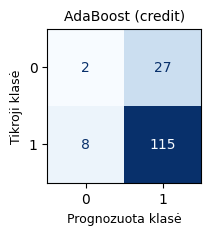

In [184]:
y_pred_credit = best_adaBoost_credit.predict(X_test_credit_tsne)

cm = confusion_matrix(y_test_credit_tsne, y_pred_credit)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (credit)', fontsize = 10)
plt.xlabel('Prognozuota klasė', fontsize = 9)
plt.ylabel('Tikroji klasė', fontsize = 9)
plt.savefig("tsne_adaboost_credit_cm.png", dpi=300, bbox_inches='tight')
plt.show()

In [185]:
y_pred = best_adaBoost_credit.predict(X_test_credit_tsne)

cm = confusion_matrix(y_test_credit_tsne, y_pred)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.7697
Specifiškumas (Specificity): 0.0690

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.200000  0.068966  0.102564  0.079365
Klasė 1   0.809859  0.934959  0.867925  0.906940


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\3720283961.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\3720283961.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


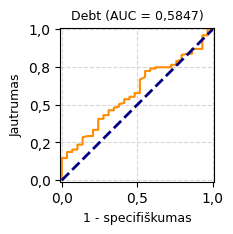

In [186]:
y_probs = best_adaBoost_credit.predict_proba(X_test_credit_tsne)[:, 1]
auc_score = roc_auc_score(y_test_credit_tsne, y_probs)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_credit, 
    X_test_credit_tsne, 
    y_test_credit_tsne, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_adaboost_credit_roc.png", dpi=300, bbox_inches='tight')
plt.show()

In [187]:
y_pred_credit = best_adaBoost_credit.predict(X_test_credit_tsne)

tn, fp, fn, tp = confusion_matrix(y_test_credit_tsne, y_pred_credit).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

youden_index = sensitivity + specificity - 1

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Youden Index: {youden_index:.4f}")

Sensitivity: 0.9350
Specificity: 0.0690
Youden Index: 0.0039


In [188]:
y_probs_credit = best_adaBoost_debt.predict_proba(X_test_credit_tsne)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_credit_tsne, y_probs_credit)
youden_scores = tpr - fpr
best_idx = np.argmax(youden_scores)
best_threshold = thresholds[best_idx]
print(f"Optimalus slenkstis (Youden): {best_threshold:.4f}")
y_pred_credit = (y_probs_credit >= best_threshold).astype(int)

Optimalus slenkstis (Youden): 0.5208


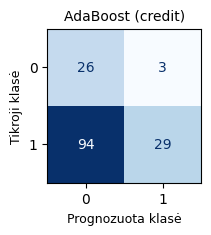

In [189]:
cm = confusion_matrix(y_test_credit_tsne, y_pred_credit)

fig, ax = plt.subplots(figsize=(2, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

plt.title('AdaBoost (credit)', fontsize=10)
plt.xlabel('Prognozuota klasė', fontsize=9)
plt.ylabel('Tikroji klasė', fontsize=9)
plt.savefig("tsne_adaboost_credit_cm_youden.png", dpi=300, bbox_inches='tight')
plt.show()

In [190]:
cm = confusion_matrix(y_test_credit_tsne, y_pred_credit)
    
n = np.sum(cm)
diag = np.diag(cm)
rowsums = np.sum(cm, axis=1)
colsums = np.sum(cm, axis=0)

accuracy = np.sum(diag) / n 

precision = diag / colsums 
recall = diag / rowsums 
f1 = 2 * precision * recall / (precision + recall) 
specificity_val = cm[0, 0] / rowsums[0]

beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

youden_index = recall[1] + specificity_val - 1  # sensitivity + specificity - 1

metrics_by_class = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1, 
    'F2': f2
}, index=['Klasė 0', 'Klasė 1'])

print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
print(f"Youden indeksas: {youden_index:.4f}")
print("\nMatai atskiroms klasėms:")
print(metrics_by_class)

Bendras tikslumas (Accuracy): 0.3618
Specifiškumas (Specificity): 0.8966
Youden indeksas: 0.1323

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.216667  0.896552  0.348993  0.550847
Klasė 1   0.906250  0.235772  0.374194  0.276718


C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1511811564.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_x)
C:\Users\crist\AppData\Local\Temp\ipykernel_35204\1511811564.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


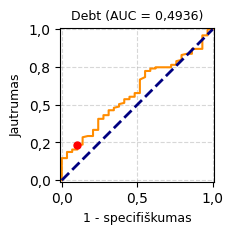

In [191]:
auc_score = roc_auc_score(y_test_credit_tsne, y_probs_credit)

fig, ax = plt.subplots(figsize=(2, 2))

RocCurveDisplay.from_estimator(
    best_adaBoost_credit, 
    X_test_credit_tsne, 
    y_test_credit_tsne, 
    ax=ax, 
    color='darkorange'
)

leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Youden taškas
ax.plot(
    fpr[best_idx], tpr[best_idx],
    marker='o', markersize=5,
    color='red', zorder=5
)

auc_str = f"{auc_score:.4f}".replace('.', ',')
plt.title(f'Debt (AUC = {auc_str})', fontsize=9)
plt.xlabel('1 - specifiškumas', fontsize = 9)
plt.ylabel('Jautrumas', fontsize = 9)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f')) # nustatom formatą
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

labels_x = [item.get_text().replace('.', ',') for item in ax.get_xticklabels()]
ax.set_xticklabels(labels_x)
labels_y = [item.get_text().replace('.', ',') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels_y)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_adaboost_credit_roc_youden.png", dpi=300, bbox_inches='tight')
plt.show()

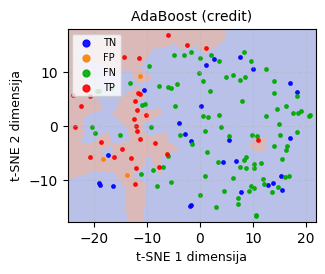

In [192]:
x_coords = X_test_credit_tsne[:, 0]
y_coords = X_test_credit_tsne[:, 1]

y_pred_youden = (best_adaBoost_credit.predict_proba(X_test_credit_tsne)[:, 1] >= best_threshold).astype(int)

xi = np.linspace(x_coords.min()-1, x_coords.max()+1, 200)
yi = np.linspace(y_coords.min()-1, y_coords.max()+1, 200)
xx, yy = np.meshgrid(xi, yi)

grid_z = griddata((x_coords, y_coords), y_pred_youden, (xx, yy), method='nearest')

plt.figure(figsize=(3.2, 2.5))
cmap_light = ListedColormap(["#7684D4", "#B97474"])
plt.pcolormesh(xx, yy, grid_z, cmap=cmap_light, shading='auto', alpha=0.5)

y_true = np.array(y_test_credit)

categories = {
    'TN': (y_true == 0) & (y_pred_youden == 0),
    'FP': (y_true == 0) & (y_pred_youden == 1),
    'FN': (y_true == 1) & (y_pred_youden == 0),
    'TP': (y_true == 1) & (y_pred_youden == 1),
}

colors = {'TN': '#0000FF', 'FP': '#FF8000', 'FN': '#00AA00', 'TP': '#FF0000'}

for label, mask in categories.items():
    plt.scatter(x_coords[mask], y_coords[mask], c=colors[label],
                label=label, s=6, alpha=0.9)

plt.title("AdaBoost (credit)", fontsize=10)
plt.xlabel("t-SNE 1 dimensija", fontsize=9)
plt.ylabel("t-SNE 2 dimensija", fontsize=9)
plt.legend(fontsize=7, markerscale=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("tsne_adaboost_credit_db.png", dpi=300, bbox_inches='tight')
plt.show()

## Random Forest

In [19]:
def random_forest_fun(X_train, X_test, y_train, y_test, params={'random_state':123}, auc=False, auc_name=None, cm_fig=False, name=None):

    classifier = RandomForestClassifier(**params)
    classifier.fit(X_train, y_train)
    
    y_pred = classifier.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    n = np.sum(cm)
    diag = np.diag(cm)
    rowsums = np.sum(cm, axis=1)
    colsums = np.sum(cm, axis=0)

    accuracy = np.sum(diag) / n 

    precision = diag / colsums 
    recall = diag / rowsums 
    f1 = 2 * precision * recall / (precision + recall) 
    specificity_val = cm[0, 0] / rowsums[0]

    beta = 2
    f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    metrics_by_class = pd.DataFrame({
        'Precision': precision,
        'Recall': recall,
        'F1': f1, 
        'F2': f2
    }, index=['Klasė 0', 'Klasė 1'])
    
    print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
    print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
    print("\nMatai atskiroms klasėms:")
    print(metrics_by_class)

    print("\nSumaišymo matrica (Confusion Matrix):")
    cm_df = pd.DataFrame(cm, 
                         index=['Tikras 0 (Neatitiko)', 'Tikras 1 (Atitiko)'], 
                         columns=['Prognozė 0', 'Prognozė 1'])
    print(cm_df)

    if cm_fig:
        width_inch = 5/2.54
        height_inch = width_inch

        fig, ax = plt.subplots(figsize=(width_inch, height_inch))
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        ax.set_xlabel('Prognozė', fontsize=9)
        ax.set_ylabel('Tikroji reikšmė', fontsize=9)
        
        ax.tick_params(axis='both', which='major', labelsize=8)
        
        for text in disp.text_.ravel():
            text.set_fontsize(10)

        plt.title('')
        plt.savefig(name, dpi=300, bbox_inches='tight')
        plt.show()

    if auc:
        fig, ax = plt.subplots(figsize=(width_inch, height_inch))

        y_probs = classifier.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_probs)
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)

        auc_text = f"{auc_score:.3f}".replace('.', ',')

        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_text}')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

        comma_fmt = mtick.FuncFormatter(lambda x, pos: f'{x:.1f}'.replace('.', ','))
        ax = plt.gca()
        ax.xaxis.set_major_formatter(comma_fmt)
        ax.yaxis.set_major_formatter(comma_fmt)

        ax.set_xlim([-0.1, 1.0])
        ax.set_xlim([-0.1, 1.05])
        ax.tick_params(axis='both', which='major', labelsize=7)
        ax.set_xlabel('1 - Specifiškumas', fontsize=8)
        ax.set_ylabel('Jautrumas', fontsize=8)
        ax.set_title('')
        ax.legend(loc="lower right", fontsize=6)
        ax.grid(True, linestyle='--', alpha=0.7)

        plt.savefig(auc_name, dpi=300, bbox_inches='tight')
        plt.show()
    
    return classifier, metrics_by_class

In [20]:
def plot_tsne_confusion(x_coords, y_coords, y_true, y_pred, title="Modelis", name=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    categories = {
        'TN': (y_true == 0) & (y_pred == 0),
        'FP': (y_true == 0) & (y_pred == 1),
        'FN': (y_true == 1) & (y_pred == 0),
        'TP': (y_true == 1) & (y_pred == 1),
    }
    colors = {'TN': '#0000FF', 'FP': '#FF8000', 'FN': '#00AA00', 'TP': '#FF0000'}

    width_inch = 8 / 2.54
    height_inch = 6.5 / 2.54

    fig, ax = plt.subplots(figsize=(width_inch, height_inch))

    for label, mask in categories.items():
        ax.scatter(x_coords[mask], y_coords[mask], c=colors[label],
                   label=label, s=6, alpha=0.9)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("t-SNE 1 dimensija", fontsize=9)
    ax.set_ylabel("t-SNE 2 dimensija", fontsize=9)
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, linestyle='--', alpha=0.3)

    if name:
        plt.savefig(f"{name}_tsne.png", dpi=300, bbox_inches='tight')
    plt.show()

In [21]:
def random_forest_youden_fun(X_train, X_test, y_train, y_test, params={'random_state':123}, auc=False, auc_name=None, cm_fig=False, name=None):
    classifier = RandomForestClassifier(**params)
    classifier.fit(X_train, y_train)
    
    y_probs = classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    
    y_pred_optimal = (y_probs >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_optimal)
    n = np.sum(cm)
    diag = np.diag(cm)
    rowsums = np.sum(cm, axis=1)
    colsums = np.sum(cm, axis=0)

    accuracy = np.sum(diag) / n 
    precision = diag / colsums 
    recall = diag / rowsums 
    f1 = 2 * precision * recall / (precision + recall) 
    specificity_val = cm[0, 0] / rowsums[0]

    beta = 2
    f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    metrics_by_class = pd.DataFrame({
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F2': f2
    }, index=['Klasė 0', 'Klasė 1'])
    
    print(f"Optimalus slenkstis pagal Youden's J: {best_threshold:.4f}")
    print(f"Bendras tikslumas (Accuracy) su Youden: {accuracy:.4f}")
    print(f"Specifiškumas (0 klasės Recall): {specificity_val:.4f}")
    print("\nMatai atskiroms klasėms (naudojant Youden slenkstį):")
    print(metrics_by_class)

    print("\nSumaišymo matrica (Confusion Matrix):")
    cm_df = pd.DataFrame(cm, 
                         index=['Tikras 0 (Neatitiko)', 'Tikras 1 (Atitiko)'], 
                         columns=['Prognozė 0', 'Prognozė 1'])
    print(cm_df)

    if cm_fig:
        width_inch = 5/2.54
        height_inch = width_inch  * 1

        fig, ax = plt.subplots(figsize=(width_inch, height_inch))
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        ax.set_xlabel('Prognozė', fontsize=9)
        ax.set_ylabel('Tikroji reikšmė', fontsize=9)
        
        ax.tick_params(axis='both', which='major', labelsize=8)
        
        for text in disp.text_.ravel():
            text.set_fontsize(10)

        plt.title('')
        plt.savefig(name, dpi=300, bbox_inches='tight')
        plt.show()

    if auc:
        fig, ax = plt.subplots(figsize=(width_inch, height_inch))

        y_probs = classifier.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_probs)
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)

        auc_text = f"{auc_score:.3f}".replace('.', ',')
        best_threshold_text = f"{thresholds[best_idx]:.2f}".replace('.', ',')

        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_text}')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

        ax.scatter(fpr[best_idx], tpr[best_idx], color='red', s=15, 
                   label=f'Slenkstis = {best_threshold_text}', zorder=5)
        
        comma_fmt = mtick.FuncFormatter(lambda x, pos: f'{x:.1f}'.replace('.', ','))
        ax.xaxis.set_major_formatter(comma_fmt)
        ax.yaxis.set_major_formatter(comma_fmt)

        ax.set_xlim([-0.1, 1.0])
        ax.set_xlim([-0.1, 1.05])
        ax.tick_params(axis='both', which='major', labelsize=7)
        ax.set_xlabel('1 - Specifiškumas', fontsize=8)
        ax.set_ylabel('Jautrumas', fontsize=8)
        ax.set_title('')
        
        ax.legend(loc="lower right", fontsize=6)
        ax.grid(True, linestyle='--', alpha=0.7)

        plt.savefig(auc_name, dpi=300, bbox_inches='tight')
        plt.show()

    return classifier, metrics_by_class, best_threshold

In [22]:
def plot_tsne_boundaries(X_set, y_set, classifier, title="Random Forest (t-SNE)", filename=None):

    x_min, x_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
    y_min, y_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
    
    step = 0.3 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))
    
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    width_inch = 8 / 2.54
    height_inch = width_inch
    
    plt.figure(figsize=(width_inch , height_inch))
    plt.contourf(xx, yy, Z, alpha = 0.25, cmap = ListedColormap(('tomato', 'springgreen')))
    
    unique_classes = np.unique(y_set)
    colors = ['red', 'green']
    
    for i, cls in enumerate(unique_classes):
        plt.scatter(X_set[y_set == cls, 0], X_set[y_set == cls, 1],
                    color = colors[i], label = f'{cls} klasė',
                    edgecolors='black', linewidth=0.1, s=7, zorder=3)
    
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title, fontsize=10)
    plt.xlabel('t-SNE 1 dimensija')
    plt.ylabel('t-SNE 2 dimensija')
    plt.legend(loc="best", fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.3)

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

In [23]:
def plot_tsne_confusion_db(x_coords, y_coords, y_true, y_pred, title="Modelis", name=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    xi = np.linspace(x_coords.min()-1, x_coords.max()+1, 200)
    yi = np.linspace(y_coords.min()-1, y_coords.max()+1, 200)
    xx, yy = np.meshgrid(xi, yi)
    grid_z = griddata((x_coords, y_coords), y_pred, (xx, yy), method='nearest')

    categories = {
        'TN': (y_true == 0) & (y_pred == 0),
        'FP': (y_true == 0) & (y_pred == 1),
        'FN': (y_true == 1) & (y_pred == 0),
        'TP': (y_true == 1) & (y_pred == 1),
    }
    colors = {'TN': '#0000FF', 'FP': '#FF8000', 'FN': '#00AA00', 'TP': '#FF0000'}

    width_inch = 8 / 2.54
    height_inch = 6.5 / 2.54

    fig, ax = plt.subplots(figsize=(width_inch, height_inch))

    cmap_light = ListedColormap(["#7684D4", "#B97474"])
    ax.pcolormesh(xx, yy, grid_z, cmap=cmap_light, shading='auto', alpha=0.5)

    for label, mask in categories.items():
        ax.scatter(x_coords[mask], y_coords[mask], c=colors[label],
                   label=label, s=6, alpha=0.9)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("t-SNE 1 dimensija", fontsize=9)
    ax.set_ylabel("t-SNE 2 dimensija", fontsize=9)
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, linestyle='--', alpha=0.3)

    if name:
        plt.savefig(f"{name}_tsne_db.png", dpi=300, bbox_inches='tight')
    plt.show()

### Skolų konsolidavimo grupė
#### Standartiniai parametrai

Originali dimensija

Bendras tikslumas (Accuracy): 0.9011
Specifiškumas (Specificity): 0.5000

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.936170  0.500000  0.651852  0.551378
Klasė 1   0.897196  0.992248  0.942331  0.971660

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          44          44
Tikras 1 (Atitiko)             3         384


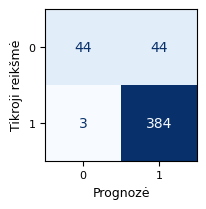

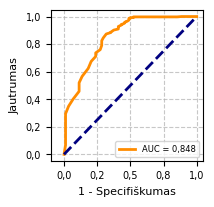

In [24]:
classifier, metrics_by_class = random_forest_fun(X_train_debt_norm, X_test_debt_norm, y_train_debt, y_test_debt, auc=True, auc_name="RF_auc_debt_1", cm_fig=True, name="RF_cm_debt_1")

Hiperparametrų atrinkimas

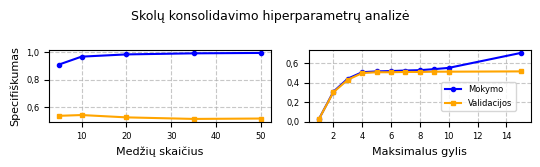

In [25]:
params = [
    {"name": "n_estimators", "range": [5, 10, 20, 35, 50], "label": "n_estimators"},
    {"name": "max_depth", "range": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15], "label": "max_depth"}
]

comma_formatter = mtick.FuncFormatter(lambda x, pos: f'{x:.1f}'.replace('.', ','))

width_inch = 14/2.54
height_inch = width_inch  * 0.3
fig, axes = plt.subplots(1, 2, figsize=(width_inch, height_inch))
axes_flat = axes.flatten()

fig.suptitle('Skolų konsolidavimo hiperparametrų analizė', fontsize=9)

for i, p in enumerate(params):

    clf = RandomForestClassifier(random_state=123)
    
    train_scores, test_scores = validation_curve(
        clf, X_train_debt_norm, y_train_debt, 
        param_name=p["name"], param_range=p["range"],
        cv=cv_strategy, scoring=specificity_scorer, n_jobs=-1
    )
    
    ax = axes_flat[i]
    ax.plot(p["range"], np.mean(train_scores, axis=1), label="Mokymo", marker='o', color='blue', markersize=3)
    ax.plot(p["range"], np.mean(test_scores, axis=1), label="Validacijos", marker='s', color='orange', markersize=3)

    x_label_lt = "Medžių skaičius" if p['name'] == "n_estimators" else "Maksimalus gylis"
    ax.set_xlabel(x_label_lt, fontsize=8)

    if i == 0:
        ax.set_ylabel("Specifiškumas", fontsize=8)

    ax.yaxis.set_major_formatter(comma_formatter)
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    ax.set_title("")
    ax.grid(True, linestyle='--', alpha=0.7)
    if i == 1: 
        ax.legend(loc='lower right', bbox_to_anchor=(0.95, 0.1), fontsize=6)

plt.savefig("RF_debt_param.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [26]:
param_grid = {
    'n_estimators': [5, 10, 20, 50, 100],
    'max_depth': [None, 1, 2, 3, 4, 6, 8, 10]
}

rf = RandomForestClassifier(random_state=123)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv_strategy, n_jobs=-1, scoring=specificity_scorer)
grid_search.fit(X_train_debt_norm, y_train_debt)

print(f"Geriausi parametrai pagal SPECIFIŠKUMĄ: {grid_search.best_params_}")
print(f"Geriausias specifiškumas (CV score, mokymo aibė): {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_debt_norm)
cm_best = confusion_matrix(y_test_debt, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Geriausi parametrai pagal SPECIFIŠKUMĄ: {'max_depth': None, 'n_estimators': 10}
Geriausias specifiškumas (CV score, mokymo aibė): 0.5428
Specifiškumas testavimo aibei: 0.5114


Bendras tikslumas (Accuracy): 0.8905
Specifiškumas (Specificity): 0.5114

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.833333  0.511364  0.633803  0.554187
Klasė 1   0.897862  0.976744  0.935644  0.959878

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          45          43
Tikras 1 (Atitiko)             9         378


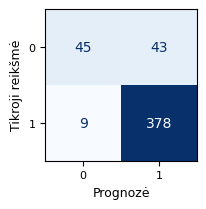

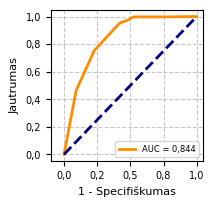

In [27]:
classifier, metrics_by_class = random_forest_fun(X_train_debt_norm, X_test_debt_norm, y_train_debt, y_test_debt, params={'n_estimators':10, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_debt_2", cm_fig=True, name="RF_cm_debt_2")

Optimalus slenkstis pagal Youden's J: 0.7000
Bendras tikslumas (Accuracy) su Youden: 0.8842
Specifiškumas (0 klasės Recall): 0.5795

Matai atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.739130  0.579545  0.649682  0.605701
Klasė 1   0.908867  0.953488  0.930643  0.944217

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          51          37
Tikras 1 (Atitiko)            18         369


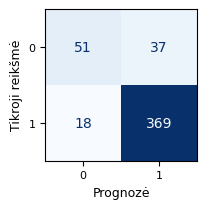

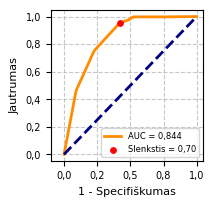

In [28]:
classifier, metrics_by_class, best_threshold = random_forest_youden_fun(X_train_debt_norm, X_test_debt_norm, y_train_debt, y_test_debt, params={'n_estimators':10, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_debt_3", cm_fig=True, name="RF_cm_debt_3")

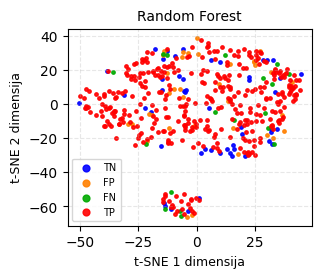

In [447]:
y_pred_youden = (classifier.predict_proba(X_test_debt_norm)[:, 1] >= best_threshold).astype(int)

plot_tsne_confusion(
    x_coords = X_test_debt_tsne[:, 0],
    y_coords = X_test_debt_tsne[:, 1],
    y_true   = y_test_debt,
    y_pred   = y_pred_youden,
    title    = "Random Forest",
    name     = "rf_debt_youden_plot"
)

t-SNE:

Bendras tikslumas (Accuracy): 0.8274
Specifiškumas (Specificity): 0.2841

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.568182  0.284091  0.378788  0.315657
Klasė 1   0.853828  0.950904  0.899756  0.929763

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          25          63
Tikras 1 (Atitiko)            19         368


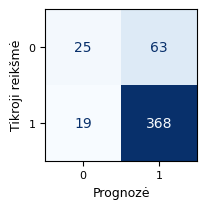

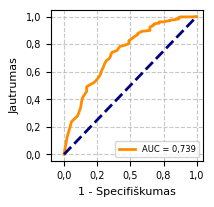

In [29]:
classifier_tsne, metrics_by_class_tsne = random_forest_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne, auc=True, auc_name="RF_auc_debt_tsne_1", cm_fig=True, name="RF_cm_debt_tsne_1")

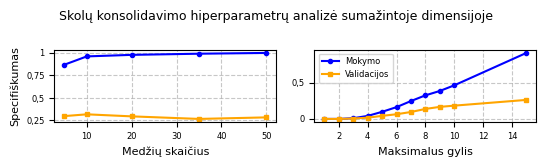

In [34]:
params = [
    {"name": "n_estimators", "range": [5, 10, 20, 35, 50], "label": "n_estimators"},
    {"name": "max_depth", "range": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15], "label": "max_depth"}
]

comma_formatter = mtick.FuncFormatter(lambda x, pos: f'{x:g}'.replace('.', ','))

width_inch = 14/2.54
height_inch = width_inch  * 0.3
fig, axes = plt.subplots(1, 2, figsize=(width_inch, height_inch))
axes_flat = axes.flatten()

fig.suptitle('Skolų konsolidavimo hiperparametrų analizė sumažintoje dimensijoje', fontsize=9)

for i, p in enumerate(params):

    clf = RandomForestClassifier(random_state=123)
    
    train_scores, test_scores = validation_curve(
        clf, X_train_debt_tsne, y_train_debt_tsne, 
        param_name=p["name"], param_range=p["range"],
        cv=cv_strategy, scoring=specificity_scorer, n_jobs=-1
    )
    
    ax = axes_flat[i]
    ax.plot(p["range"], np.mean(train_scores, axis=1), label="Mokymo", marker='o', color='blue', markersize=3)
    ax.plot(p["range"], np.mean(test_scores, axis=1), label="Validacijos", marker='s', color='orange', markersize=3)

    x_label_lt = "Medžių skaičius" if p['name'] == "n_estimators" else "Maksimalus gylis"
    ax.set_xlabel(x_label_lt, fontsize=8)

    if i == 0:
        ax.set_ylabel("Specifiškumas", fontsize=8)

    ax.yaxis.set_major_formatter(comma_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    ax.set_title("")
    ax.grid(True, linestyle='--', alpha=0.7)
    if i == 1: 
        ax.legend(loc='upper left', fontsize=6)

plt.savefig("RF_debt_tsne_param.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [35]:
param_grid = {
    'n_estimators': [5, 10, 20, 50, 100],
    'max_depth': [None, 1, 2, 3, 4, 6, 8, 10]
}

rf = RandomForestClassifier(random_state=123)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv_strategy, n_jobs=-1, scoring=specificity_scorer)
grid_search.fit(X_train_debt_tsne, y_train_debt_tsne)

print(f"Geriausi parametrai pagal SPECIFIŠKUMĄ: {grid_search.best_params_}")
print(f"Geriausias specifiškumas (CV score, mokymo aibė): {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_debt_tsne)
cm_best = confusion_matrix(y_test_debt_tsne, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Geriausi parametrai pagal SPECIFIŠKUMĄ: {'max_depth': None, 'n_estimators': 10}
Geriausias specifiškumas (CV score, mokymo aibė): 0.3181
Specifiškumas testavimo aibei: 0.3409


Bendras tikslumas (Accuracy): 0.8147
Specifiškumas (Specificity): 0.3409

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.500000  0.340909  0.405405  0.364078
Klasė 1   0.860241  0.922481  0.890274  0.909322

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          30          58
Tikras 1 (Atitiko)            30         357


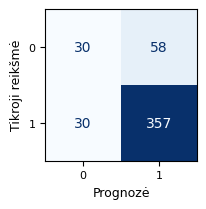

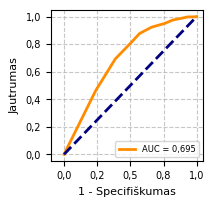

In [36]:
classifier, metrics_by_class = random_forest_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne, params={'n_estimators':10, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_debt_tsne_2", cm_fig=True, name="RF_cm_debt_tsne_2")

Optimalus slenkstis pagal Youden's J: 0.7000
Bendras tikslumas (Accuracy) su Youden: 0.7937
Specifiškumas (0 klasės Recall): 0.4318

Matai atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.441860  0.431818  0.436782  0.433790
Klasė 1   0.871465  0.875969  0.873711  0.875065

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          38          50
Tikras 1 (Atitiko)            48         339


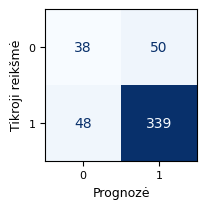

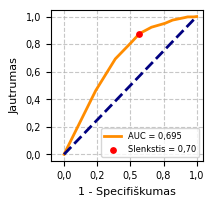

In [37]:
classifier, metrics_by_class, best_threshold = random_forest_youden_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne, params={'n_estimators':10, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_debt_tsne_3", cm_fig=True, name="RF_cm_debt_tsne_3")

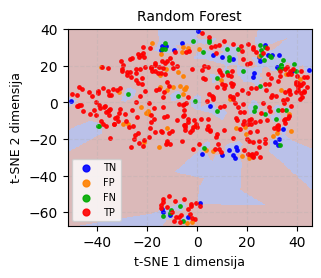

In [450]:
y_pred_youden_tsne = (classifier.predict_proba(X_test_debt_tsne)[:, 1] >= best_threshold).astype(int)

plot_tsne_confusion_db(
    x_coords = X_test_debt_tsne[:, 0],
    y_coords = X_test_debt_tsne[:, 1],
    y_true   = y_test_debt_tsne,
    y_pred   = y_pred_youden_tsne,
    title    = "Random Forest",
    name     = "rf_debt_tsne_yd_plot"
)

### Kredito kortelės grupė

Originali

Bendras tikslumas (Accuracy): 0.8750
Specifiškumas (Specificity): 0.5172

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.750000  0.517241  0.612245  0.551471
Klasė 1   0.893939  0.959350  0.925490  0.945513

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          15          14
Tikras 1 (Atitiko)             5         118


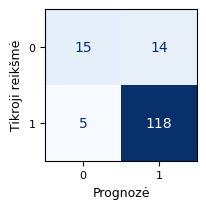

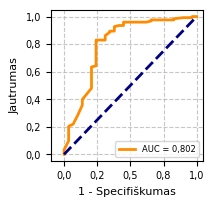

In [38]:
classifier, metrics_by_class = random_forest_fun(X_train_credit_norm, X_test_credit_norm, y_train_credit, y_test_credit, auc=True, auc_name="RF_auc_credit_1", cm_fig=True, name="RF_cm_credit_1")

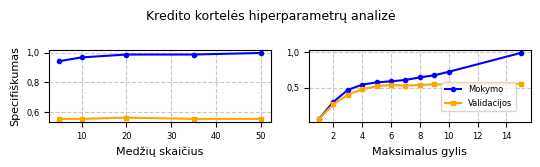

In [39]:
params = [
    {"name": "n_estimators", "range": [5, 10, 20, 35, 50], "label": "n_estimators"},
    {"name": "max_depth", "range": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15], "label": "max_depth"}
]

comma_formatter = mtick.FuncFormatter(lambda x, pos: f'{x:.1f}'.replace('.', ','))

width_inch = 14/2.54
height_inch = width_inch  * 0.3
fig, axes = plt.subplots(1, 2, figsize=(width_inch, height_inch))
axes_flat = axes.flatten()

fig.suptitle('Kredito kortelės hiperparametrų analizė', fontsize=9)

for i, p in enumerate(params):

    clf = RandomForestClassifier(random_state=123)
    
    train_scores, test_scores = validation_curve(
        clf, X_train_credit_norm, y_train_credit, 
        param_name=p["name"], param_range=p["range"],
        cv=cv_strategy, scoring=specificity_scorer, n_jobs=-1
    )
    
    ax = axes_flat[i]
    ax.plot(p["range"], np.mean(train_scores, axis=1), label="Mokymo", marker='o', color='blue', markersize=3)
    ax.plot(p["range"], np.mean(test_scores, axis=1), label="Validacijos", marker='s', color='orange', markersize=3)

    x_label_lt = "Medžių skaičius" if p['name'] == "n_estimators" else "Maksimalus gylis"
    ax.set_xlabel(x_label_lt, fontsize=8)

    if i == 0:
        ax.set_ylabel("Specifiškumas", fontsize=8)

    ax.yaxis.set_major_formatter(comma_formatter)
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    ax.set_title("")
    ax.grid(True, linestyle='--', alpha=0.7)
    if i == 1: 
        ax.legend(loc='lower right', bbox_to_anchor=(0.95, 0.1), fontsize=6)

plt.savefig("RF_credit_param.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [40]:
param_grid = {
    'n_estimators': [5, 10, 20, 50, 100],
    'max_depth': [None, 1, 2, 3, 4, 6, 8, 10]
}

rf = RandomForestClassifier(random_state=123)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv_strategy, n_jobs=-1, scoring=specificity_scorer)
grid_search.fit(X_train_credit_norm, y_train_credit)

print(f"Geriausi parametrai pagal SPECIFIŠKUMĄ: {grid_search.best_params_}")
print(f"Geriausias specifiškumas (CV score, mokymo aibė): {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_credit_norm)
cm_best = confusion_matrix(y_test_credit, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")


Geriausi parametrai pagal SPECIFIŠKUMĄ: {'max_depth': None, 'n_estimators': 20}
Geriausias specifiškumas (CV score, mokymo aibė): 0.5620
Specifiškumas testavimo aibei: 0.4483


Bendras tikslumas (Accuracy): 0.8487
Specifiškumas (Specificity): 0.4483

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.650000  0.448276  0.530612  0.477941
Klasė 1   0.878788  0.943089  0.909804  0.929487

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          13          16
Tikras 1 (Atitiko)             7         116


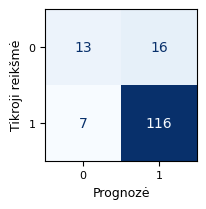

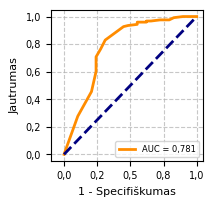

In [41]:
classifier, metrics_by_class = random_forest_fun(X_train_credit_norm, X_test_credit_norm, y_train_credit, y_test_credit, params={'n_estimators':20, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_credit_2", cm_fig=True, name="RF_cm_credit_2")

Optimalus slenkstis pagal Youden's J: 0.7500
Bendras tikslumas (Accuracy) su Youden: 0.8026
Specifiškumas (0 klasės Recall): 0.6897

Matai atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.487805  0.689655  0.571429  0.636943
Klasė 1   0.918919  0.829268  0.871795  0.845771

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          20           9
Tikras 1 (Atitiko)            21         102


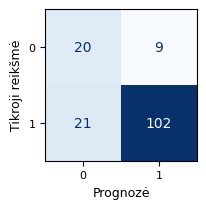

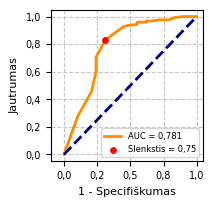

In [42]:
classifier, metrics_by_class, best_threshold = random_forest_youden_fun(X_train_credit_norm, X_test_credit_norm, y_train_credit, y_test_credit, params={'n_estimators':20, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_credit_3", cm_fig=True, name="RF_cm_credit_3")

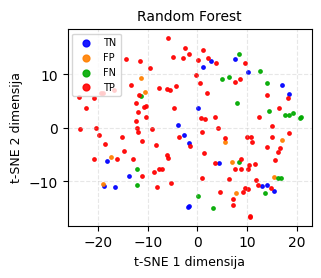

In [453]:
y_pred_youden = (classifier.predict_proba(X_test_credit_norm)[:, 1] >= best_threshold).astype(int)

plot_tsne_confusion(
    x_coords = X_test_credit_tsne[:, 0],
    y_coords = X_test_credit_tsne[:, 1],
    y_true   = y_test_credit,
    y_pred   = y_pred_youden,
    title    = "Random Forest",
    name     = "rf_credit_youden_plot"
)

t-SNE

Bendras tikslumas (Accuracy): 0.7763
Specifiškumas (Specificity): 0.3103

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.391304  0.310345  0.346154  0.323741
Klasė 1   0.844961  0.886179  0.865079  0.877617

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)           9          20
Tikras 1 (Atitiko)            14         109


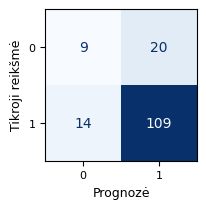

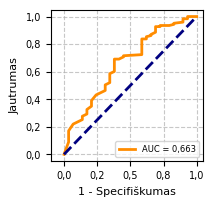

In [43]:
classifier_tsne, metrics_by_class_tsne = random_forest_fun(X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne, auc=True, auc_name="RF_auc_credit_tsne_1", cm_fig=True, name="RF_cm_credit_tsne_1")

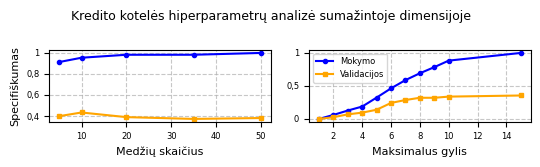

In [45]:
params = [
    {"name": "n_estimators", "range": [5, 10, 20, 35, 50], "label": "n_estimators"},
    {"name": "max_depth", "range": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15], "label": "max_depth"}
]

comma_formatter = mtick.FuncFormatter(lambda x, pos: f'{x:g}'.replace('.', ','))

width_inch = 14/2.54
height_inch = width_inch  * 0.3
fig, axes = plt.subplots(1, 2, figsize=(width_inch, height_inch))
axes_flat = axes.flatten()

fig.suptitle('Kredito kotelės hiperparametrų analizė sumažintoje dimensijoje', fontsize=9)

for i, p in enumerate(params):

    clf = RandomForestClassifier(random_state=123)
    
    train_scores, test_scores = validation_curve(
        clf, X_train_credit_tsne, y_train_credit_tsne, 
        param_name=p["name"], param_range=p["range"],
        cv=cv_strategy, scoring=specificity_scorer, n_jobs=-1
    )
    
    ax = axes_flat[i]
    ax.plot(p["range"], np.mean(train_scores, axis=1), label="Mokymo", marker='o', color='blue', markersize=3)
    ax.plot(p["range"], np.mean(test_scores, axis=1), label="Validacijos", marker='s', color='orange', markersize=3)

    x_label_lt = "Medžių skaičius" if p['name'] == "n_estimators" else "Maksimalus gylis"
    ax.set_xlabel(x_label_lt, fontsize=8)

    if i == 0:
        ax.set_ylabel("Specifiškumas", fontsize=8)

    ax.yaxis.set_major_formatter(comma_formatter)
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    ax.set_title("")
    ax.grid(True, linestyle='--', alpha=0.7)
    if i == 1: 
        ax.legend(loc='upper left', fontsize=6)

plt.savefig("RF_credit_tsne_param.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [50]:
param_grid = {
    'n_estimators': [5, 10, 20, 50, 100],
    'max_depth': [None, 1, 2, 3, 4, 6, 8, 10]
}

rf = RandomForestClassifier(random_state=123)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv_strategy, n_jobs=-1, scoring=specificity_scorer)
grid_search.fit(X_train_credit_tsne, y_train_credit_tsne)

print(f"Geriausi parametrai pagal SPECIFIŠKUMĄ: {grid_search.best_params_}")
print(f"Geriausias specifiškumas (CV score, mokymo aibė): {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_credit_tsne)
cm_best = confusion_matrix(y_test_credit_tsne, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Geriausi parametrai pagal SPECIFIŠKUMĄ: {'max_depth': None, 'n_estimators': 10}
Geriausias specifiškumas (CV score, mokymo aibė): 0.4337
Specifiškumas testavimo aibei: 0.2759


Bendras tikslumas (Accuracy): 0.7434
Specifiškumas (Specificity): 0.2759

Matai atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.307692  0.275862  0.290909  0.281690
Klasė 1   0.833333  0.853659  0.843373  0.849515

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)           8          21
Tikras 1 (Atitiko)            18         105


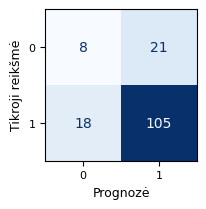

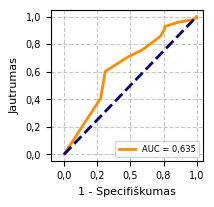

In [454]:
classifier, metrics_by_class = random_forest_fun(X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne, params={'n_estimators':10, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_credit_tsne_2", cm_fig=True, name="RF_cm_credit_tsne_2")

Optimalus slenkstis pagal Youden's J: 0.9000
Bendras tikslumas (Accuracy) su Youden: 0.6184
Specifiškumas (0 klasės Recall): 0.6897

Matai atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.289855  0.689655  0.408163  0.540541
Klasė 1   0.891566  0.601626  0.718447  0.643478

Sumaišymo matrica (Confusion Matrix):
                      Prognozė 0  Prognozė 1
Tikras 0 (Neatitiko)          20           9
Tikras 1 (Atitiko)            49          74


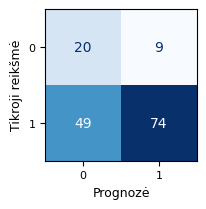

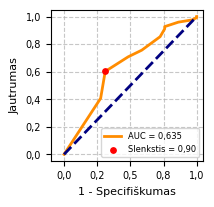

In [455]:
classifier, metrics_by_class, best_threshold = random_forest_youden_fun(X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne, params={'n_estimators':10, 'max_depth':None, 'random_state':123}, auc=True, auc_name="RF_auc_credit_tsne_3", cm_fig=True, name="RF_cm_credit_tsne_3")

C:\Users\rugil\AppData\Local\Temp\ipykernel_50144\308632350.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{name}_tsne_db.png", dpi=300, bbox_inches='tight')


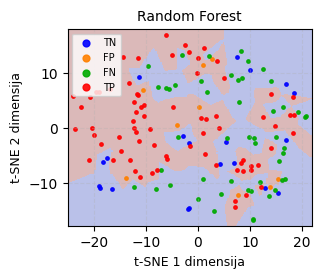

In [457]:
y_pred_youden_tsne = (classifier.predict_proba(X_test_credit_tsne)[:, 1] >= best_threshold).astype(int)

plot_tsne_confusion_db(
    x_coords = X_test_credit_tsne[:, 0],
    y_coords = X_test_credit_tsne[:, 1],
    y_true   = y_test_credit_tsne,
    y_pred   = y_pred_youden_tsne,
    title    = "Random Forest",
    name     = "rf_credit_tsne_yd_plot"
)

## Gradient boosting

In [385]:
def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

def gradient_boosting_fun(X_train, X_test, y_train, y_test, params={'random_state': 123}, auc=False, cm_fig=False, name=None):
    classifier = GradientBoostingClassifier(**params)
    classifier.fit(X_train, y_train)
    
    y_pred = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    n = np.sum(cm)
    diag = np.diag(cm)
    rowsums = np.sum(cm, axis=1)
    colsums = np.sum(cm, axis=0)

    accuracy = np.sum(diag) / n 
    precision = diag / colsums
    recall = diag / rowsums
    f1 = 2 * precision * recall / (precision + recall)
    specificity_val = cm[0, 0] / rowsums[0]
    
    beta = 2
    f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    metrics_by_class = pd.DataFrame({
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F2': f2
    }, index=['Klasė 0', 'Klasė 1'])

    print(f"Bendras tikslumas (Accuracy): {accuracy:.4f}")
    print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
    print("\nMetrikos atskiroms klasėms:")
    print(metrics_by_class)

    width_inch = 5 / 2.54
    height_inch = width_inch

    if cm_fig:
        fig, ax = plt.subplots(figsize=(width_inch, height_inch))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_xlabel('Prognozė', fontsize=9)
        ax.set_ylabel('Tikroji reikšmė', fontsize=9)
        ax.tick_params(axis='both', which='major', labelsize=8)
        
        for text in disp.text_.ravel():
            text.set_fontsize(10)

        if name:
            plt.savefig(f"{name}_cm.png", dpi=300, bbox_inches='tight')
        plt.show()

    if auc:
        y_probs = classifier.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_probs)
        fpr, tpr, _ = roc_curve(y_test, y_probs)

        fig, ax = plt.subplots(figsize=(width_inch, height_inch))
        
        auc_str = f"{auc_score:.3f}".replace('.', ',')
        
        ax.plot(fpr, tpr, color='darkorange', lw=1.5, label=f'AUC={auc_str}')
        ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('1 - Specifiškumas', fontsize=8)
        ax.set_ylabel('Jautrumas', fontsize=8)
        
        ax.xaxis.set_major_formatter(FuncFormatter(comma_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(comma_formatter))
        
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        ax.legend(loc="lower right", prop={'size': 6}, frameon=True)
        
        if name:
            plt.savefig(f"{name}_auc.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    return classifier, metrics_by_class

In [386]:
def gradient_boosting_youden_fun(X_train, X_test, y_train, y_test, params={'random_state': 123}, auc=False, cm_fig=False, name=None):
    classifier = GradientBoostingClassifier(**params)
    classifier.fit(X_train, y_train)
    
    y_probs = classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    
    y_pred_optimal = (y_probs >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_optimal)
    n = np.sum(cm)
    diag = np.diag(cm)
    rowsums = np.sum(cm, axis=1)
    colsums = np.sum(cm, axis=0)

    accuracy = np.sum(diag) / n 
    precision = diag / colsums 
    recall = diag / rowsums 
    f1 = 2 * precision * recall / (precision + recall) 
    specificity_val = cm[0, 0] / rowsums[0]

    beta = 2
    f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    metrics_by_class = pd.DataFrame({
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F2': f2
    }, index=['Klasė 0', 'Klasė 1'])
    
    print(f"Optimalus slenkstis pagal Youden's J: {best_threshold:.4f}")
    print(f"Bendras tikslumas (Accuracy) su Youden: {accuracy:.4f}")
    print(f"Specifiškumas (Specificity): {specificity_val:.4f}")
    print("\nMetrikos atskiroms klasėms (naudojant Youden slenkstį):")
    print(metrics_by_class)

    width_inch = 5 / 2.54
    height_inch = width_inch

    if cm_fig:
        fig, ax = plt.subplots(figsize=(width_inch, height_inch))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_xlabel('Prognozė', fontsize=9)
        ax.set_ylabel('Tikroji reikšmė', fontsize=9)
        ax.tick_params(axis='both', which='major', labelsize=8)
        
        for text in disp.text_.ravel():
            text.set_fontsize(10)

        if name:
            plt.savefig(f"{name}_cm_youden.png", dpi=300, bbox_inches='tight')
        plt.show()

    if auc:
        auc_score = roc_auc_score(y_test, y_probs)
        fig, ax = plt.subplots(figsize=(width_inch, height_inch))
        
        auc_str = f"{auc_score:.3f}".replace('.', ',')
        thr_str = f"{best_threshold:.3f}".replace('.', ',')
        
        ax.plot(fpr, tpr, color='darkorange', lw=1.5, label=f'AUC={auc_str}')
        ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        

        ax.scatter(fpr[best_idx], tpr[best_idx], color='red', s=15, 
                   label=f'Slenkstis={thr_str}', zorder=5)
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('1 - Specifiškumas', fontsize=8)
        ax.set_ylabel('Jautrumas', fontsize=8)
        
        ax.xaxis.set_major_formatter(FuncFormatter(comma_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(comma_formatter))
        
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        ax.legend(loc="lower right", prop={'size': 5.5}, frameon=True)
        
        if name:
            plt.savefig(f"{name}_auc_youden.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    return classifier, metrics_by_class, best_threshold

### Skolų konsolidavimo grupė
#### Standartiniai parametrai

Originali dimensija

Bendras tikslumas (Accuracy): 0.9053
Specifiškumas (Specificity): 0.5114

Metrikos atskiroms klasėms:
         Precision    Recall        F1       F2
Klasė 0   0.957447  0.511364  0.666667  0.56391
Klasė 1   0.899533  0.994832  0.944785  0.97419


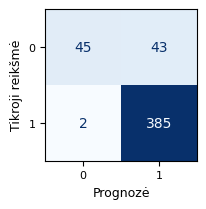

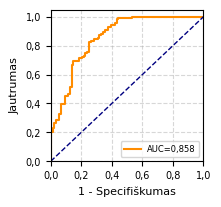

In [405]:
classifier, metrics_by_class = gradient_boosting_fun(X_train_debt_norm, X_test_debt_norm, y_train_debt, y_test_debt, auc=True, cm_fig=True, name="gb_debt_stand")

In [104]:
# #  Gauname spėjimus iš modelio, kuris mokėsi iš ORIGINALŲ duomenų
# y_pred_orig = classifier.predict(X_test_debt_norm)

# plt.figure(figsize=(10, 7))
# colors = ['red', 'green']
# class_names = ['Neatitiko (0)', 'Atitiko (1)']

# for i, cls in enumerate([0, 1]):
#     # Atrandame taškus, kuriuos ORIGINALUS modelis priskyrė šiai klasei
#     # Šiai kaukei naudojame y_pred_orig, o koordinatėms - X_test_tsne
#     mask = (y_pred_orig == cls)
    
#     plt.scatter(X_test_debt_norm[mask, 0], X_test_debt_norm[mask, 1], 
#                 color=colors[i], 
#                 label=f'Modelis spėja: {class_names[i]}', 
#                 alpha=0.6, edgecolors='black', s=50)

# plt.title("Originalaus modelio (Gradient Boosting) prognozės t-SNE erdvėje", fontsize=14)
# plt.xlabel("t-SNE 1 dimensija")
# plt.ylabel("t-SNE 2 dimensija")
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.3)
# plt.show()

In [ ]:
# plot_tsne_boundaries(X_train_debt_tsne, y_train_debt_tsne, classifier, 
#                      title="Random Forest (Training set - t-SNE)")

# plot_tsne_boundaries(X_test_debt_tsne, y_test_debt_tsne, classifier, 
#                      title="Random Forest (Test set - t-SNE)")

In [ ]:
# classifier_tsne, metrics_by_class_tsne = gradient_boosting_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne)

In [ ]:
# plot_tsne_boundaries(X_train_debt_tsne, y_train_debt_tsne, classifier_tsne, 
#                      title="Random Forest (Training set - t-SNE)")

# plot_tsne_boundaries(X_test_debt_tsne, y_test_debt_tsne, classifier_tsne, 
#                      title="Random Forest (Test set - t-SNE)")

Hiperparametrų atrinkimas

Skaičiuojama n_estimators kreivė...
Skaičiuojama learning_rate kreivė...
Skaičiuojama max_depth kreivė...
Skaičiuojama subsample kreivė...


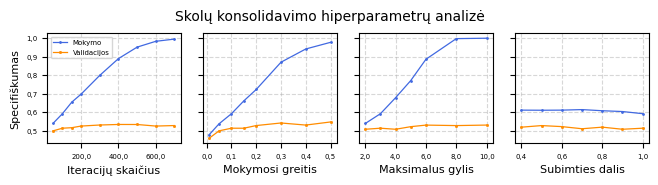

In [406]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300, 400, 500, 600, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'subsample': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

labels_lt = {
    'n_estimators': 'Iteracijų skaičius',
    'learning_rate': 'Mokymosi greitis',
    'max_depth': 'Maksimalus gylis',
    'subsample': 'Subimties dalis'
}

def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

width_inch = 17 / 2.54
height_inch = width_inch * 0.3

fig, axes = plt.subplots(1, 4, figsize=(width_inch , height_inch), sharey=True)
axes = axes.flatten() 

fig.suptitle("Skolų konsolidavimo hiperparametrų analizė", fontsize=10, y=0.9)

for i, (param_name, param_range) in enumerate(param_grid.items()):
    print(f"Skaičiuojama {param_name} kreivė...")
    
    train_scores, test_scores = validation_curve(
        GradientBoostingClassifier(random_state=123),
        X_train_debt_norm, y_train_debt,
        param_name=param_name,
        param_range=param_range,
        cv=cv_strategy,
        scoring=specificity_scorer,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[i].plot(param_range, train_mean, label="Mokymo", marker='o', color='royalblue', markersize=1, linewidth=0.9)
    axes[i].plot(param_range, test_mean, label="Validacijos", marker='s', color='darkorange', markersize=1, linewidth=0.9)
    

    pavadinimas_lt = labels_lt.get(param_name, param_name)
    # axes[i].set_title(pavadinimas_lt, fontsize=7)
    axes[i].set_xlabel(pavadinimas_lt, fontsize=8)

    if i == 0:
        axes[i].set_ylabel("Specifiškumas", fontsize=8)

    axes[i].tick_params(axis='both', labelsize=5)
    axes[i].yaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].grid(True, linestyle='--', alpha=0.5)

    if i == 0:
        axes[i].legend(prop={'size': 5}, loc="best", frameon=True)

plt.tight_layout()
plt.savefig("gradient_boosting_hiperparam.png", dpi=300, bbox_inches='tight')
plt.show()

In [407]:
param_grid = {
    'n_estimators': [100, 300, 600],
    'learning_rate': [0.1, 0.3, 0.5],
    'max_depth': [3, 4, 6, 8],
    'subsample': [0.8, 0.9, 1.0]
}

gbc = GradientBoostingClassifier(random_state=123)

grid_search_debt = GridSearchCV(estimator=gbc, 
                                param_grid=param_grid, 
                                cv=5, 
                                n_jobs=-1, 
                                scoring=specificity_scorer, 
                                verbose=1)

grid_search_debt.fit(X_train_debt_norm, y_train_debt)

print(f"Geriausi parametrai (Debt): {grid_search_debt.best_params_}")
print(f"Geriausias tikslumas (CV): {grid_search_debt.best_score_:.4f}")

best_model_gbc_debt = grid_search_debt.best_estimator_
y_pred_best = best_model_gbc_debt.predict(X_test_debt_norm)
cm_best = confusion_matrix(y_test_debt, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Geriausi parametrai (Debt): {'learning_rate': 0.5, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Geriausias tikslumas (CV): 0.5681
Specifiškumas testavimo aibei: 0.5341


In [408]:
cm_best

array([[ 47,  41],
       [ 19, 368]])

Bendras tikslumas (Accuracy): 0.8737
Specifiškumas (Specificity): 0.5341

Metrikos atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.712121  0.534091  0.610390  0.562201
Klasė 1   0.899756  0.950904  0.924623  0.940215


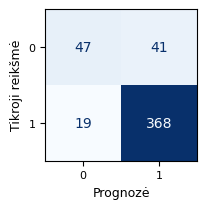

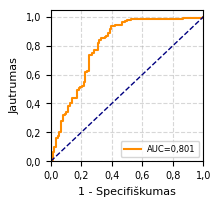

In [409]:
classifier, metrics_by_class = gradient_boosting_fun(X_train_debt_norm, X_test_debt_norm, y_train_debt, y_test_debt, params={'learning_rate':0.5, 
                                                                                                                             'max_depth':4, 
                                                                                                                             'n_estimators': 100,
                                                                                                                             'subsample':0.8,
                                                                                                                             'random_state':123}, auc=True, cm_fig=True, name="gb_debt_opt")

Optimalus slenkstis pagal Youden's J: 0.7559
Bendras tikslumas (Accuracy) su Youden: 0.8737
Specifiškumas (Specificity): 0.6023

Metrikos atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.679487  0.602273  0.638554  0.616279
Klasė 1   0.911839  0.935401  0.923469  0.930591


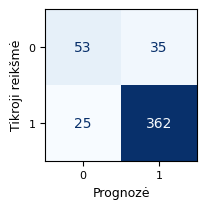

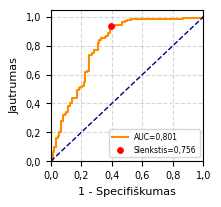

In [421]:
classifier, metrics_by_class, best_threshold = gradient_boosting_youden_fun(X_train_debt_norm, X_test_debt_norm, y_train_debt, y_test_debt, params={'learning_rate':0.5, 
                                                                                                                             'max_depth':4, 
                                                                                                                             'n_estimators': 100,
                                                                                                                             'subsample':0.8,
                                                                                                                             'random_state':123}, auc=True, cm_fig=True, name="gb_debt")

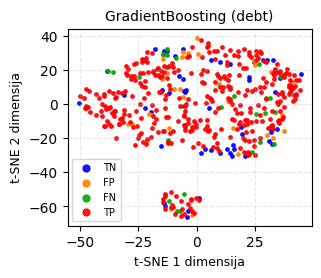

In [423]:
y_pred_youden = (classifier.predict_proba(X_test_debt_norm)[:, 1] >= best_threshold).astype(int)

plot_tsne_confusion(
    x_coords = X_test_debt_tsne[:, 0],
    y_coords = X_test_debt_tsne[:, 1],
    y_true   = y_test_debt,
    y_pred   = y_pred_youden,
    title    = "GradientBoosting (debt)",
    name     = "gb_debt_youden_plot"
)

t-SNE

Bendras tikslumas (Accuracy): 0.8189
Specifiškumas (Specificity): 0.1250

Metrikos atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.550000  0.125000  0.203704  0.147849
Klasė 1   0.830769  0.976744  0.897862  0.943585


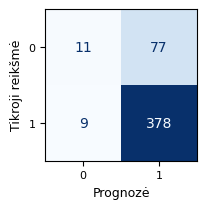

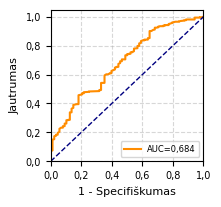

In [427]:
classifier_tsne, metrics_by_class_tsne = gradient_boosting_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne, auc=True, cm_fig=True, name="gb_debt_stand_tsne")

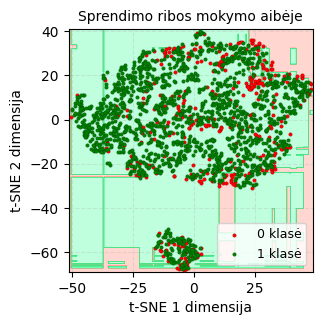

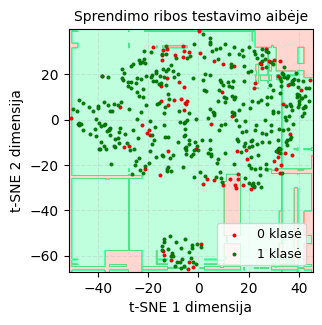

In [394]:
plot_tsne_boundaries(X_train_debt_tsne, y_train_debt_tsne, classifier_tsne, 
                     title="Sprendimo ribos mokymo aibėje", filename = "debt_tsne_boundaries_train.png")

plot_tsne_boundaries(X_test_debt_tsne, y_test_debt_tsne, classifier_tsne, 
                     title="Sprendimo ribos testavimo aibėje", filename = "debt_tsne_boundaries_test.png")

Skaičiuojama n_estimators kreivė...
Skaičiuojama learning_rate kreivė...
Skaičiuojama max_depth kreivė...
Skaičiuojama subsample kreivė...


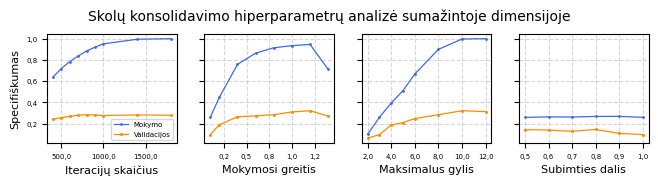

In [413]:
param_grid = {
    'n_estimators': [400, 500, 600, 700, 800, 900, 1000, 1400, 1800],
    'learning_rate': [0.1, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4],
    'max_depth': [2, 3, 4, 5, 6, 8, 10, 12],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

labels_lt = {
    'n_estimators': 'Iteracijų skaičius',
    'learning_rate': 'Mokymosi greitis',
    'max_depth': 'Maksimalus gylis',
    'subsample': 'Subimties dalis'
}

def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

width_inch = 17 / 2.54
height_inch = width_inch * 0.3

fig, axes = plt.subplots(1, 4, figsize=(width_inch , height_inch), sharey=True)
axes = axes.flatten() 

fig.suptitle("Skolų konsolidavimo hiperparametrų analizė sumažintoje dimensijoje", fontsize=10, y=0.9)


for i, (param_name, param_range) in enumerate(param_grid.items()):
    print(f"Skaičiuojama {param_name} kreivė...")
    
    train_scores, test_scores = validation_curve(
        GradientBoostingClassifier(random_state=123),
        X_train_debt_tsne, y_train_debt_tsne,
        param_name=param_name,
        param_range=param_range,
        cv=cv_strategy,
        scoring=specificity_scorer,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[i].plot(param_range, train_mean, label="Mokymo", marker='o', color='royalblue', markersize=1, linewidth=0.9)
    axes[i].plot(param_range, test_mean, label="Validacijos", marker='s', color='darkorange', markersize=1, linewidth=0.9)
    
    pavadinimas_lt = labels_lt.get(param_name, param_name)
    # axes[i].set_title(pavadinimas_lt, fontsize=7)
    axes[i].set_xlabel(pavadinimas_lt, fontsize=8)

    if i == 0:
        axes[i].set_ylabel("Specifiškumas", fontsize=8)

    axes[i].tick_params(axis='both', labelsize=5)
    axes[i].yaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].grid(True, linestyle='--', alpha=0.5)

    if i == 0:
        axes[i].legend(prop={'size': 5}, loc="best", frameon=True)

plt.tight_layout()
plt.savefig("gradient_boosting_hiperparam_tsne.png", dpi=300, bbox_inches='tight')
plt.show()

In [396]:
param_grid = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'learning_rate': [0.8, 1.0, 1.2],
    'max_depth': [3, 6, 8, 10],
    'subsample': [0.8, 0.9, 1.0]
}

gbc = GradientBoostingClassifier(random_state=123)

grid_search_debt = GridSearchCV(estimator=gbc, 
                                param_grid=param_grid, 
                                cv=5, 
                                n_jobs=-1, 
                                scoring=specificity_scorer, 
                                verbose=1)

grid_search_debt.fit(X_train_debt_tsne, y_train_debt_tsne)

print(f"Geriausi parametrai (Debt): {grid_search_debt.best_params_}")
print(f"Geriausias tikslumas (CV): {grid_search_debt.best_score_:.4f}")

best_model_gbc_debt = grid_search_debt.best_estimator_
y_pred_best = best_model_gbc_debt.predict(X_test_debt_tsne)
cm_best = confusion_matrix(y_test_debt_tsne, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Geriausi parametrai (Debt): {'learning_rate': 1.2, 'max_depth': 6, 'n_estimators': 600, 'subsample': 0.8}
Geriausias tikslumas (CV): 0.4115
Specifiškumas testavimo aibei: 0.2386


Bendras tikslumas (Accuracy): 0.7537
Specifiškumas (Specificity): 0.2386

Metrikos atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.295775  0.238636  0.264151  0.248227
Klasė 1   0.834158  0.870801  0.852086  0.863217


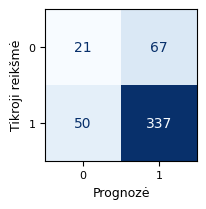

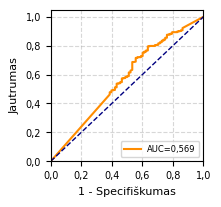

In [428]:
classifier_tsne, metrics_by_class_tsne= gradient_boosting_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne, params={'n_estimators':600, 
                                                                                                                                                        'learning_rate':1.2,
                                                                                                                                                        'subsample': 0.8,
                                                                                                                                                        'max_depth':6, 
                                                                                                                                                        'random_state':123}, auc=True, cm_fig=True, name="gb_debt_opt_tsne")

Optimalus slenkstis pagal Youden's J: 0.9849
Bendras tikslumas (Accuracy) su Youden: 0.7158
Specifiškumas (Specificity): 0.3636

Metrikos atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.288288  0.363636  0.321608  0.345572
Klasė 1   0.846154  0.795866  0.820240  0.805439


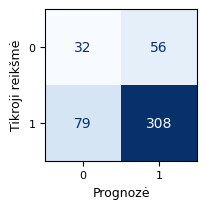

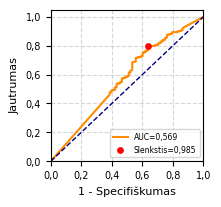

In [429]:
classifier_tsne_yd, metrics_by_class_tsne_yd, best_threshold_tsne_yd = gradient_boosting_youden_fun(X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne, params={'n_estimators':600, 
                                                                                                                                                        'learning_rate':1.2,
                                                                                                                                                        'subsample': 0.8,
                                                                                                                                                        'max_depth':6, 
                                                                                                                                                        'random_state':123}, auc=True, cm_fig=True, name="gb_debt_tsne")

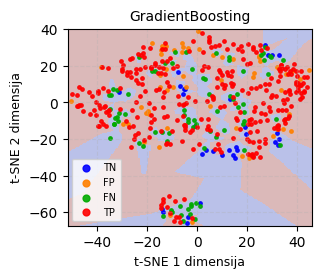

In [430]:
y_pred_youden_tsne = (classifier_tsne_yd.predict_proba(X_test_debt_tsne)[:, 1] >= best_threshold_tsne_yd).astype(int)

plot_tsne_confusion_db(
    x_coords = X_test_debt_tsne[:, 0],
    y_coords = X_test_debt_tsne[:, 1],
    y_true   = y_test_debt_tsne,
    y_pred   = y_pred_youden_tsne,
    title    = "GradientBoosting",
    name     = "gb_debt_tsne_yd_plot"
)

### Kredito kortelės grupė

Orginali dimensija

Bendras tikslumas (Accuracy): 0.8947
Specifiškumas (Specificity): 0.6207

Metrikos atskiroms klasėms:
         Precision   Recall        F1        F2
Klasė 0   0.782609  0.62069  0.692308  0.647482
Klasė 1   0.914729  0.95935  0.936508  0.950081


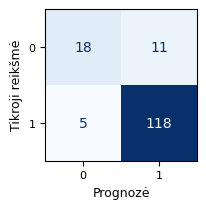

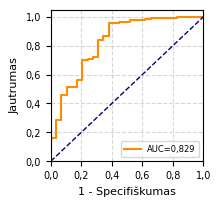

In [465]:
classifier, metrics_by_class = gradient_boosting_fun(X_train_credit_norm, X_test_credit_norm, y_train_credit, y_test_credit, auc=True, cm_fig=True, name="gb_credit_stand")

Skaičiuojama n_estimators kreivė...
Skaičiuojama learning_rate kreivė...
Skaičiuojama max_depth kreivė...
Skaičiuojama subsample kreivė...


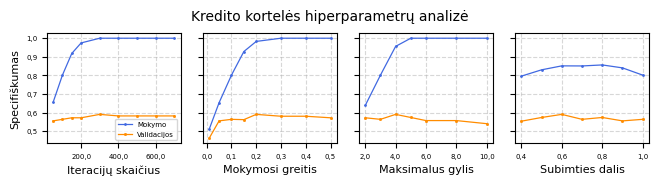

In [415]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300, 400, 500, 600, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'subsample': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

labels_lt = {
    'n_estimators': 'Iteracijų skaičius',
    'learning_rate': 'Mokymosi greitis',
    'max_depth': 'Maksimalus gylis',
    'subsample': 'Subimties dalis'
}

def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

width_inch = 17 / 2.54
height_inch = width_inch * 0.3

fig, axes = plt.subplots(1, 4, figsize=(width_inch , height_inch), sharey=True)
axes = axes.flatten() 

fig.suptitle("Kredito kortelės hiperparametrų analizė", fontsize=10, y=0.9)

for i, (param_name, param_range) in enumerate(param_grid.items()):
    print(f"Skaičiuojama {param_name} kreivė...")
    
    train_scores, test_scores = validation_curve(
        GradientBoostingClassifier(random_state=123),
        X_train_credit_norm, y_train_credit,
        param_name=param_name,
        param_range=param_range,
        cv=cv_strategy,
        scoring=specificity_scorer,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[i].plot(param_range, train_mean, label="Mokymo", marker='o', color='royalblue', markersize=1, linewidth=0.9)
    axes[i].plot(param_range, test_mean, label="Validacijos", marker='s', color='darkorange', markersize=1, linewidth=0.9)
    

    pavadinimas_lt = labels_lt.get(param_name, param_name)
    # axes[i].set_title(pavadinimas_lt, fontsize=7)
    axes[i].set_xlabel(pavadinimas_lt, fontsize=8)

    if i == 0:
        axes[i].set_ylabel("Specifiškumas", fontsize=8)

    axes[i].tick_params(axis='both', labelsize=5)
    axes[i].yaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].grid(True, linestyle='--', alpha=0.5)

    if i == 0:
        axes[i].legend(prop={'size': 5}, loc="best", frameon=True)

plt.tight_layout()
plt.savefig("gradient_boosting_hiperparam_credit.png", dpi=300, bbox_inches='tight')
plt.show()

In [466]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.25, 0.3],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.8, 0.9, 1.0]
}

gbc = GradientBoostingClassifier(random_state=123)

grid_search_credit = GridSearchCV(estimator=gbc, 
                                param_grid=param_grid, 
                                cv=5, 
                                n_jobs=-1, 
                                scoring=specificity_scorer, 
                                verbose=1)

grid_search_credit.fit(X_train_credit_norm, y_train_credit)

print(f"Geriausi parametrai (Credit): {grid_search_credit.best_params_}")
print(f"Geriausias tikslumas (CV): {grid_search_credit.best_score_:.4f}")

best_model_gbc_credit = grid_search_credit.best_estimator_
y_pred_best = best_model_gbc_credit.predict(X_test_credit_norm)
cm_best = confusion_matrix(y_test_credit, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Fitting 5 folds for each of 600 candidates, totalling 3000 fits
Geriausi parametrai (Credit): {'learning_rate': 0.25, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Geriausias tikslumas (CV): 0.6207
Specifiškumas testavimo aibei: 0.5862


Bendras tikslumas (Accuracy): 0.8618
Specifiškumas (Specificity): 0.5862

Metrikos atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.653846  0.586207  0.618182  0.598592
Klasė 1   0.904762  0.926829  0.915663  0.922330


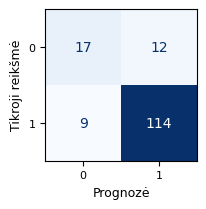

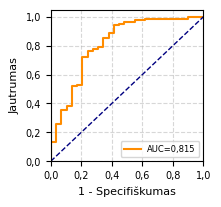

In [467]:
classifier, metrics_by_class = gradient_boosting_fun(X_train_credit_norm, X_test_credit_norm, y_train_credit, y_test_credit, params={'learning_rate':0.25, 
                                                                                                                             'max_depth':5, 
                                                                                                                             'n_estimators': 100,
                                                                                                                             'subsample':0.8,
                                                                                                                             'random_state':123}, auc=True, cm_fig=True, name="gb_credit_opt")

Optimalus slenkstis pagal Youden's J: 0.4360
Bendras tikslumas (Accuracy) su Youden: 0.8750
Specifiškumas (Specificity): 0.5862

Metrikos atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.708333  0.586207  0.641509  0.607143
Klasė 1   0.906250  0.943089  0.924303  0.935484


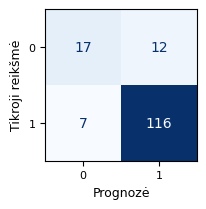

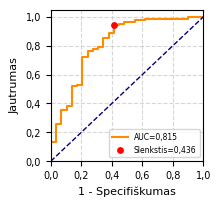

In [468]:
classifier, metrics_by_class, best_threshold = gradient_boosting_youden_fun(X_train_credit_norm, X_test_credit_norm, y_train_credit, y_test_credit, params={'learning_rate':0.25, 
                                                                                                                             'max_depth':5, 
                                                                                                                             'n_estimators': 100,
                                                                                                                             'subsample':0.8,
                                                                                                                             'random_state':123}, auc=True, cm_fig=True, name="gb_credit")

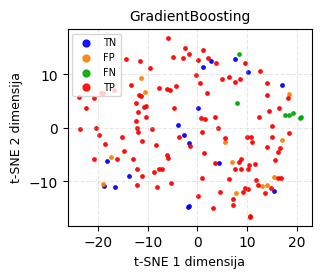

In [425]:
y_pred_youden = (classifier.predict_proba(X_test_credit_norm)[:, 1] >= best_threshold).astype(int)

plot_tsne_confusion(
    x_coords = X_test_credit_tsne[:, 0],
    y_coords = X_test_credit_tsne[:, 1],
    y_true   = y_test_credit,
    y_pred   = y_pred_youden,
    title    = "GradientBoosting",
    name     = "gb_credit_youden_plot"
)

t-SNE

Bendras tikslumas (Accuracy): 0.7763
Specifiškumas (Specificity): 0.2414

Metrikos atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.368421  0.241379  0.291667  0.259259
Klasė 1   0.834586  0.902439  0.867188  0.888000


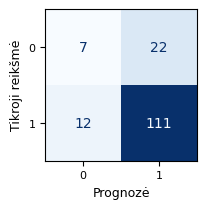

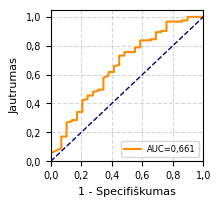

In [431]:
classifier_tsne, metrics_by_class_tsne = gradient_boosting_fun(X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne, auc=True, cm_fig=True, name="gb_credit_stand_tsne")

Skaičiuojama n_estimators kreivė...
Skaičiuojama learning_rate kreivė...
Skaičiuojama max_depth kreivė...
Skaičiuojama subsample kreivė...


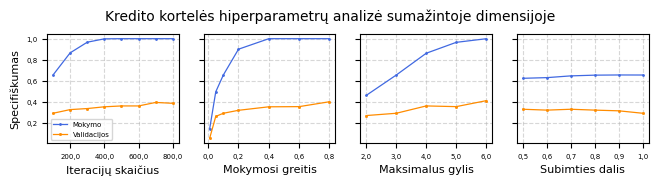

In [285]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8],
    'max_depth': [2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

labels_lt = {
    'n_estimators': 'Iteracijų skaičius',
    'learning_rate': 'Mokymosi greitis',
    'max_depth': 'Maksimalus gylis',
    'subsample': 'Subimties dalis'
}

def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

width_inch = 17 / 2.54
height_inch = width_inch * 0.3

fig, axes = plt.subplots(1, 4, figsize=(width_inch , height_inch), sharey=True)
axes = axes.flatten() 

fig.suptitle("Kredito kortelės hiperparametrų analizė sumažintoje dimensijoje", fontsize=10, y=0.9)


for i, (param_name, param_range) in enumerate(param_grid.items()):
    print(f"Skaičiuojama {param_name} kreivė...")
    
    train_scores, test_scores = validation_curve(
        GradientBoostingClassifier(random_state=123),
        X_train_credit_tsne, y_train_credit_tsne,
        param_name=param_name,
        param_range=param_range,
        cv=cv_strategy,
        scoring=specificity_scorer,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[i].plot(param_range, train_mean, label="Mokymo", marker='o', color='royalblue', markersize=1, linewidth=0.9)
    axes[i].plot(param_range, test_mean, label="Validacijos", marker='s', color='darkorange', markersize=1, linewidth=0.9)
    
    pavadinimas_lt = labels_lt.get(param_name, param_name)
    # axes[i].set_title(pavadinimas_lt, fontsize=7)
    axes[i].set_xlabel(pavadinimas_lt, fontsize=8)

    if i == 0:
        axes[i].set_ylabel("Specifiškumas", fontsize=8)

    axes[i].tick_params(axis='both', labelsize=5)
    axes[i].yaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    axes[i].grid(True, linestyle='--', alpha=0.5)

    if i == 0:
        axes[i].legend(prop={'size': 5}, loc="best", frameon=True)

plt.tight_layout()
plt.savefig("gradient_boosting_hiperparam_tsne_credit.png", dpi=300, bbox_inches='tight')
plt.show()

In [287]:
param_grid = {
    'n_estimators': [100, 200, 400, 600, 700],
    'learning_rate': [0.1, 0.2, 0.4, 0.6, 0.8],
    'max_depth': [2, 3, 4, 6],
    'subsample': [0.8, 0.9, 1.0]
}

gbc = GradientBoostingClassifier(random_state=123)

grid_search_credit = GridSearchCV(estimator=gbc, 
                                param_grid=param_grid, 
                                cv=5, 
                                n_jobs=-1, 
                                scoring=specificity_scorer, 
                                verbose=1)

grid_search_credit.fit(X_train_credit_tsne, y_train_credit_tsne)

print(f"Geriausi parametrai (credit): {grid_search_credit.best_params_}")
print(f"Geriausias tikslumas (CV): {grid_search_credit.best_score_:.4f}")

best_model_gbc_credit = grid_search_credit.best_estimator_
y_pred_best = best_model_gbc_credit.predict(X_test_credit_tsne)
cm_best = confusion_matrix(y_test_credit_tsne, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
test_specificity = tn / (tn + fp)
print(f"Specifiškumas testavimo aibei: {test_specificity:.4f}")

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Geriausi parametrai (credit): {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
Geriausias tikslumas (CV): 0.4217
Specifiškumas testavimo aibei: 0.3793


Bendras tikslumas (Accuracy): 0.7500
Specifiškumas (Specificity): 0.3793

Metrikos atskiroms klasėms:
         Precision    Recall        F1        F2
Klasė 0   0.354839  0.379310  0.366667  0.374150
Klasė 1   0.851240  0.837398  0.844262  0.840131


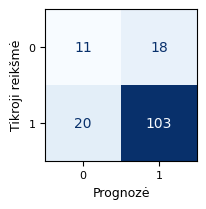

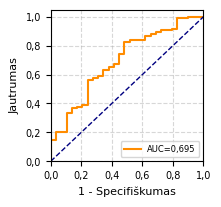

In [432]:
classifier_tsne, metrics_by_class_tsne= gradient_boosting_fun(X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne, params={'n_estimators':400, 
                                                                                                                                                        'learning_rate':0.2,
                                                                                                                                                        'subsample': 0.8,
                                                                                                                                                        'max_depth':3, 
                                                                                                                                                        'random_state':123}, auc=True, cm_fig=True, name="gb_credit_opt_tsne")

Optimalus slenkstis pagal Youden's J: 0.6590
Bendras tikslumas (Accuracy) su Youden: 0.7697
Specifiškumas (Specificity): 0.5172

Metrikos atskiroms klasėms (naudojant Youden slenkstį):
         Precision    Recall        F1        F2
Klasė 0   0.416667  0.517241  0.461538  0.493421
Klasė 1   0.879310  0.829268  0.853556  0.838816


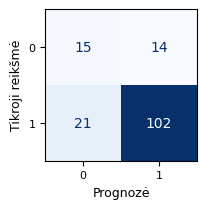

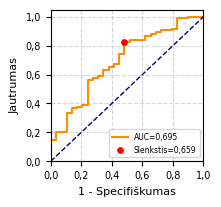

In [433]:
classifier_tsne, metrics_by_class_tsne, best_threshold_tsne_yd = gradient_boosting_youden_fun(X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne, params={'n_estimators':400, 
                                                                                                                                                        'learning_rate':0.2,
                                                                                                                                                        'subsample': 0.8,
                                                                                                                                                        'max_depth':3, 
                                                                                                                                                        'random_state':123}, auc=True, cm_fig=True, name="gb_credit_tsne")

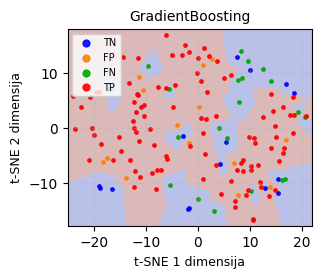

In [434]:
y_pred_youden_tsne = (classifier_tsne.predict_proba(X_test_credit_tsne)[:, 1] >= best_threshold_tsne_yd).astype(int)

plot_tsne_confusion_db(
    x_coords = X_test_credit_tsne[:, 0],
    y_coords = X_test_credit_tsne[:, 1],
    y_true   = y_test_credit_tsne,
    y_pred   = y_pred_youden_tsne,
    title    = "GradientBoosting",
    name     = "gb_credit_tsne_yd_plot"
)

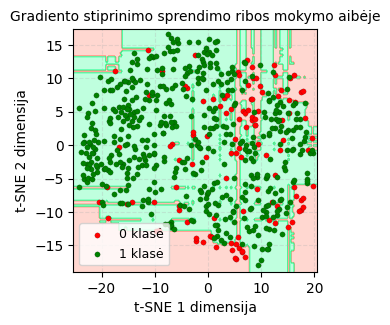

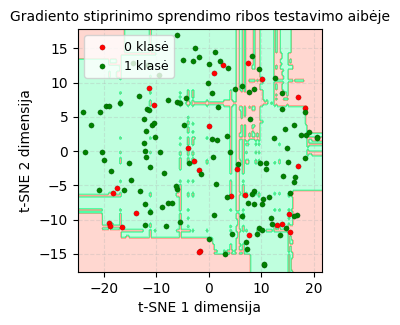

In [305]:
plot_tsne_boundaries(X_train_credit_tsne, y_train_credit_tsne, classifier_tsne, 
                     title="Gradiento stiprinimo sprendimo ribos mokymo aibėje", filename = "credit_tsne_boundaries_train.png")

plot_tsne_boundaries(X_test_credit_tsne, y_test_credit_tsne, classifier_tsne, 
                     title="Gradiento stiprinimo sprendimo ribos testavimo aibėje", filename = "credit_tsne_boundaries_test.png")